# EDA — Componente A: Detección de Anomalías en Campañas Agrícolas

Análisis exploratorio de `data/processed/panel_nucleo.parquet` (merge puro de 4 fuentes, sin feature engineering).

**Región núcleo pampeana** · 26 departamentos × soja y maíz · campañas 1981/82–2024/25

Este notebook es el análisis exploratorio orientado al **diseño e implementación del autoencoder (AE)** para la detección no supervisada de campañas anómalas (Componente A del sistema integrado).

El notebook sigue un hilo conductor en cuatro etapas:

1. **Contexto del panel** — estructura, faltantes y señal temporal del target  
2. **Ground truth proxy** — etiquetado formal de campañas anómalas (insumo de validación y filtro del train del AE)  
3. **Espacio de features del AE** — correlación, dimensionalidad y separabilidad normal/anómala  
4. **Variabilidad departamental** — justificación de la normalización por departamento  

Al final se exportan los tres artefactos que consume el notebook del autoencoder.

---

**Principios de diseño respetados en todo el notebook:**
- `rinde_kgha` y sus derivados **nunca** son features del AE — solo se usan para etiquetar y como filtro de filas válidas (sin leakage del target).
- Sin `dropna()` global — el NDVI es NaN estructural pre-2002 (MODIS). Los NaN se manejan localmente.
- Toda estadística de normalización se calcula **exclusivamente sobre train**.
- Soja y maíz se analizan por separado cuando sus escalas difieren (~2 700 vs ~6 700 kg/ha).

**Splits temporales:** `train` ≤ 2017 · `val` 2018–2020 · `test` 2021–2024 (incluye la sequía 2022/23).

## 0. Setup

In [31]:
import warnings
import numpy as np
import pandas as pd
from pathlib import Path

# pyarrow debe inicializarse antes que numba/llvmlite (umap)
ROOT = Path.cwd()
if not (ROOT / "data").exists(): ROOT = ROOT.parent

panel_path = ROOT / "data" / "processed" / "panel_nucleo.parquet"

if not panel_path.exists():
    raise FileNotFoundError("El archivo 'panel_nucleo.parquet' no se encuentra en la ruta esperada. Ejecuta el script de procesamiento de datos para generar este archivo.")

_PANEL = pd.read_parquet(panel_path)

try:
    import umap
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "umap-learn"])
    import umap

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from matplotlib.patches import Ellipse
from scipy.stats import mannwhitneyu

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60)
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "bold"
RANDOM_STATE = 42

In [58]:
df = _PANEL.copy()

# Splits temporales 
def asignar_split(y):
    if y <= 2017: return "train"
    if y <= 2020: return "val"
    return "test"
df["split"] = df["campania_inicio"].apply(asignar_split)

# Familias de columnas 
TARGET     = "rinde_kgha"
ONI_COLS   = ["oni_oct", "oni_nov", "oni_dic", "oni_ene", "oni_feb"]
MAGYP_COLS = ["sup_sembrada_ha", "sup_cosechada_ha", "produccion_tn"]
NDVI_COLS  = [c for c in df.columns if c.startswith("ndvi")]
VAR_ORDER  = ["t2m", "t2m_max", "t2m_min", "prectotcorr", "rh2m", "allsky_sfc_sw_dwn", "ws2m"]
MESES      = ["sep", "oct", "nov", "dic", "ene", "feb", "mar"]
NASA_COLS  = [f"{v}_{m}" for v in VAR_ORDER for m in MESES if f"{v}_{m}" in df.columns]

def nasa_var_cols(var):
    """Columnas mensuales de una variable NASA, ordenadas sep→mar."""
    return [c for c in NASA_COLS if c.rsplit("_", 1)[0] == var]

# Paletas 
CROP_COLORS = {"soja": "#2ca02c", "maiz": "#ff7f0e"}
ENSO_COLORS = {"Nina": "#1f77b4", "Neutro": "grey", "Nino": "#d62728"}
ANOM_COLORS = {"normal": "#2ca02c", "anomala": "#d62728"}
PROV_COLORS = {"SANTA FE": "#1f77b4", "CORDOBA": "#ff7f0e", "BUENOS AIRES": "#2ca02c"}
SEQUIAS     = {1988: "1988/89", 2008: "2008/09", 2017: "2017/18", 2022: "2022/23"}

print("Panel:", df.shape, "| NASA_COLS:", len(NASA_COLS), "| NDVI:", len(NDVI_COLS))
print(df.groupby("split")["campania_inicio"].agg(["min", "max", "count"]))

numeric_columns = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_columns = df.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"\nNumeric columns: {len(numeric_columns)}, Categorical columns: {len(categorical_columns)}")
print(f"Categorical columns: {categorical_columns}")

df.head()

Panel: (2287, 70) | NASA_COLS: 49 | NDVI: 4
        min   max  count
split                   
test   2021  2024    208
train  1981  2017   1923
val    2018  2020    156

Numeric columns: 65, Categorical columns: 5
Categorical columns: ['cultivo', 'provincia', 'departamento', 'campania', 'split']


,cultivo,campania_inicio,provincia,departamento,sup_sembrada_ha,sup_cosechada_ha,produccion_tn,rinde_kgha,lat_centroide,lon_centroide,campania,oni_dic,oni_ene,oni_feb,oni_nov,oni_oct,allsky_sfc_sw_dwn_dic,allsky_sfc_sw_dwn_ene,allsky_sfc_sw_dwn_feb,allsky_sfc_sw_dwn_mar,allsky_sfc_sw_dwn_nov,allsky_sfc_sw_dwn_oct,allsky_sfc_sw_dwn_sep,prectotcorr_dic,prectotcorr_ene,prectotcorr_feb,prectotcorr_mar,prectotcorr_nov,prectotcorr_oct,prectotcorr_sep,...,t2m_mar,t2m_nov,t2m_oct,t2m_sep,t2m_max_dic,t2m_max_ene,t2m_max_feb,t2m_max_mar,t2m_max_nov,t2m_max_oct,t2m_max_sep,t2m_min_dic,t2m_min_ene,t2m_min_feb,t2m_min_mar,t2m_min_nov,t2m_min_oct,t2m_min_sep,ws2m_dic,ws2m_ene,ws2m_feb,ws2m_mar,ws2m_nov,ws2m_oct,ws2m_sep,ndvi_mean,ndvi_min,ndvi_max,ndvi_anomalia_pct,split
0,soja,1981,BUENOS AIRES,Arrecifes,29000,29000.0,64000.0,2207.0,-34.07,-60.10,1981/82,-0.08,-0.05,0.07,-0.15,-0.13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.595806,6.057419,3.620357,3.433226,3.298333,2.325161,1.395000,...,22.057419,20.464667,17.167742,13.126000,31.757097,32.229355,28.703571,29.363226,27.812333,24.960000,20.556333,15.753871,16.680323,15.472143,15.656129,13.510000,10.216452,6.740333,2.377419,2.391290,2.435357,2.148065,2.778333,2.617097,2.893000,NaN,NaN,NaN,NaN,train
1,soja,1981,BUENOS AIRES,Baradero,18500,18500.0,37000.0,2000.0,-33.81,-59.51,1981/82,-0.08,-0.05,0.07,-0.15,-0.13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.731935,4.506452,3.667143,3.003548,2.684000,1.715484,1.455000,...,22.273226,20.473000,17.029355,12.927667,31.651613,32.405484,29.015714,29.650000,27.740000,24.486129,19.865667,15.823871,16.844194,15.871786,15.955484,13.746000,10.372903,6.914333,2.228387,2.305161,2.334643,2.086452,2.612333,2.376129,2.705333,NaN,NaN,NaN,NaN,train
2,soja,1981,BUENOS AIRES,Capitan Sarmiento,8000,8000.0,14000.0,1750.0,-34.18,-59.79,1981/82,-0.08,-0.05,0.07,-0.15,-0.13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.595806,6.057419,3.620357,3.433226,3.298333,2.325161,1.395000,...,22.057419,20.464667,17.167742,13.126000,31.757097,32.229355,28.703571,29.363226,27.812333,24.960000,20.556333,15.753871,16.680323,15.472143,15.656129,13.510000,10.216452,6.740333,2.377419,2.391290,2.435357,2.148065,2.778333,2.617097,2.893000,NaN,NaN,NaN,NaN,train
3,soja,1981,BUENOS AIRES,Carmen De Areco,5000,5000.0,10500.0,2100.0,-34.38,-59.82,1981/82,-0.08,-0.05,0.07,-0.15,-0.13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.337097,4.668387,4.040000,4.078710,3.146000,2.111290,1.298000,...,21.687742,19.755667,16.598065,12.694667,31.661935,32.095806,28.400000,29.017742,26.938667,24.290645,19.932333,15.335806,16.361935,14.946071,15.240645,12.982667,9.687742,6.397333,2.616452,2.607097,2.618214,2.309677,2.913333,2.696129,2.924333,NaN,NaN,NaN,NaN,train
4,soja,1981,BUENOS AIRES,Chacabuco,23000,23000.0,49000.0,2130.0,-34.64,-60.47,1981/82,-0.08,-0.05,0.07,-0.15,-0.13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.201290,5.562581,4.152500,4.200968,3.792333,2.569032,1.201333,...,21.488710,19.584667,16.506774,12.857333,30.969355,31.350645,27.637500,28.319032,26.376667,23.845161,20.159333,15.369032,16.477742,14.899643,15.245806,12.923667,9.780645,6.635333,2.571290,2.550968,2.562143,2.293226,2.810000,2.680645,2.876667,NaN,NaN,NaN,NaN,train


In [54]:
df.describe()

,campania_inicio,sup_sembrada_ha,sup_cosechada_ha,produccion_tn,rinde_kgha,lat_centroide,lon_centroide,oni_dic,oni_ene,oni_feb,oni_nov,oni_oct,allsky_sfc_sw_dwn_dic,allsky_sfc_sw_dwn_ene,allsky_sfc_sw_dwn_feb,allsky_sfc_sw_dwn_mar,allsky_sfc_sw_dwn_nov,allsky_sfc_sw_dwn_oct,allsky_sfc_sw_dwn_sep,prectotcorr_dic,prectotcorr_ene,prectotcorr_feb,prectotcorr_mar,prectotcorr_nov,prectotcorr_oct,prectotcorr_sep,rh2m_dic,rh2m_ene,rh2m_feb,rh2m_mar,...,t2m_feb,t2m_mar,t2m_nov,t2m_oct,t2m_sep,t2m_max_dic,t2m_max_ene,t2m_max_feb,t2m_max_mar,t2m_max_nov,t2m_max_oct,t2m_max_sep,t2m_min_dic,t2m_min_ene,t2m_min_feb,t2m_min_mar,t2m_min_nov,t2m_min_oct,t2m_min_sep,ws2m_dic,ws2m_ene,ws2m_feb,ws2m_mar,ws2m_nov,ws2m_oct,ws2m_sep,ndvi_mean,ndvi_min,ndvi_max,ndvi_anomalia_pct
count,2287.000000,2287.000000,2287.000000,2.287000e+03,2287.000000,2287.000000,2287.000000,2287.000000,2287.00000,2287.000000,2287.000000,2287.000000,2131.000000,2183.000000,2183.000000,2183.000000,2131.000000,2131.000000,2131.000000,2287.000000,2287.000000,2287.000000,2287.000000,2287.000000,2287.000000,2287.000000,2287.000000,2287.000000,2287.000000,2287.000000,...,2287.000000,2287.000000,2287.000000,2287.000000,2287.000000,2287.000000,2287.000000,2287.000000,2287.000000,2287.000000,2287.000000,2287.000000,2287.000000,2287.000000,2287.000000,2287.000000,2287.000000,2287.000000,2287.000000,2287.000000,2287.000000,2287.000000,2287.000000,2287.000000,2287.000000,2287.000000,1196.000000,1196.000000,1196.000000,1196.000000
mean,2002.507215,89913.458679,86971.913424,3.233237e+05,4740.223000,-33.669777,-60.967822,0.030162,0.03948,0.049047,0.026559,0.029602,26.270451,25.920817,22.774978,18.758379,24.581073,20.468694,16.897185,3.905673,3.924562,4.285704,4.235375,3.799754,3.710795,1.898830,59.914772,59.869350,65.392023,70.233351,...,23.584426,21.242773,20.864580,17.625390,13.976132,30.925866,32.407044,30.456257,27.994468,28.265488,24.958560,21.368880,16.282418,18.067323,17.099518,15.192174,13.686688,10.807196,7.602414,2.171698,2.007257,1.927874,1.923353,2.358779,2.390758,2.374830,0.584190,0.473713,0.690062,99.369728
std,12.699289,117584.830091,115356.641797,4.164963e+05,2628.377492,0.612026,1.021927,1.161092,1.09431,0.940568,1.127091,1.016791,1.707973,1.350591,1.874419,1.426263,1.443367,1.665063,1.296081,2.295480,1.655998,2.641307,2.499160,1.598776,1.871354,1.418838,7.998545,7.606344,7.487812,7.414063,...,1.266948,1.628008,1.481784,1.182259,1.131125,2.120146,1.843841,1.765313,2.054399,1.968446,1.710703,1.496880,1.401900,1.221761,1.259858,1.626234,1.290877,1.178511,1.213152,0.855068,0.815930,0.790874,0.799874,0.898504,0.882312,0.850682,0.086283,0.105698,0.109301,6.076256
min,1981.000000,1500.000000,1500.000000,2.500000e+03,697.000000,-34.640000,-63.420000,-1.850000,-1.69000,-1.520000,-1.800000,-1.640000,21.621935,21.866129,17.341429,14.237742,20.160000,15.668065,13.454667,0.165161,0.892581,0.271786,0.365484,0.304333,0.370000,0.000667,38.494194,42.788065,42.285357,45.162258,...,20.152500,17.466129,17.351000,13.958710,11.473667,26.745484,27.365806,25.547857,23.658065,23.574667,19.534194,18.022333,12.816774,14.712581,14.030357,11.328387,9.834667,8.161935,4.983667,0.148710,0.046129,0.018276,0.017742,0.229333,0.294839,0.368000,0.300878,0.241962,0.352000,67.468420
25%,1992.000000,19000.000000,17652.000000,8.140000e+04,2625.000000,-34.200000,-61.470000,-0.865000,-0.79500,-0.730000,-0.880000,-0.700000,25.199032,25.111290,21.524871,17.863226,23.599000,19.261290,15.906667,2.107742,2.668387,2.287931,2.617419,2.620833,2.365806,0.827500,53.315484,54.669677,60.917069,65.299839,...,22.737321,20.138226,19.892000,16.809355,13.108167,29.186774,31.182258,29.417321,26.426935,26.884333,23.791290,20.304833,15.233548,17.208871,16.107321,14.065161,12.886500,9.964839,6.668167,1.794677,1.589194,1.545536,1.523387,1.963000,2.027419,1.939833,0.549810,0.381682,0.654859,96.564496
50%,2003.000000,44000.000000,42500.000000,1.740000e+05,3763.000000,-33.680000,-60.730000,-0.150000,-0.19000,-0.020000,-0.270000,-0.220000

---
## 1. Contexto del panel

Antes de construir el etiquetado de anomalías, verificamos la estructura del panel y el comportamiento del target para entender qué tipo de variabilidad existe y cuánto de ella se debe al clima (señal del AE) versus a la mejora tecnológica (tendencia secular que hay que separar).

### 1.1 Estructura y cobertura

Filas: 2287 | Duplicados en clave (cultivo, depto, campaña): 0
Campañas: 1981–2024 (44 años) | Departamentos: 26 | Cultivos: ['soja', 'maiz']

Faltantes promedio por fuente:
  MAGyP :   0.0%
  ONI   :   0.0%
  NASA  :   0.8%
  NDVI  :  47.7%
  Target 'rinde_kgha': 0 NaN


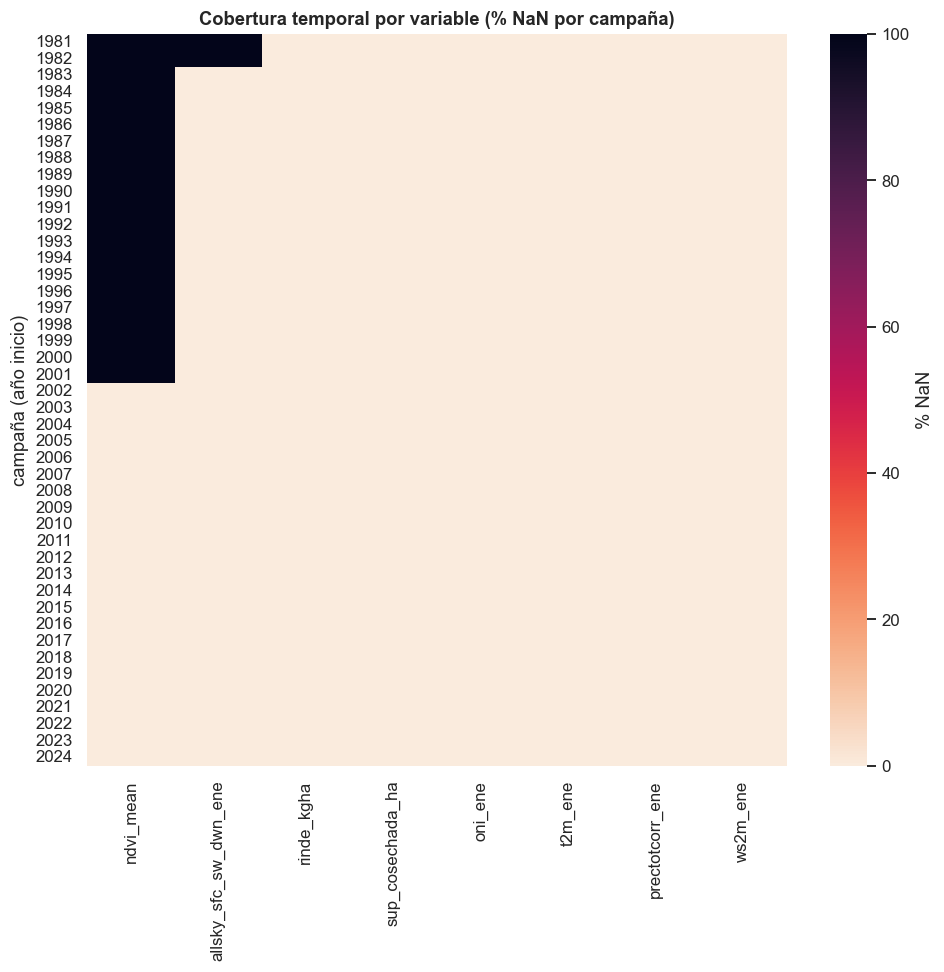

In [36]:
print(f"Filas: {len(df)} | Duplicados en clave (cultivo, depto, campaña): "
      f"{df.duplicated(['cultivo', 'departamento', 'campania_inicio']).sum()}")
print(f"Campañas: {df['campania_inicio'].min()}–{df['campania_inicio'].max()} "
      f"({df['campania_inicio'].nunique()} años) | Departamentos: {df['departamento'].nunique()} "
      f"| Cultivos: {df['cultivo'].unique().tolist()}")

print("\nFaltantes promedio por fuente:")
for name, cols in [("MAGyP", MAGYP_COLS), ("ONI", ONI_COLS), ("NASA", NASA_COLS), ("NDVI", NDVI_COLS)]:
    print(f"  {name:6s}: {df[cols].isna().mean().mean()*100:5.1f}%")
print(f"  Target '{TARGET}': {df[TARGET].isna().sum()} NaN")

# Cobertura temporal de faltantes por variable representativa
rep_cols = ["ndvi_mean", "allsky_sfc_sw_dwn_ene", "rinde_kgha", "sup_cosechada_ha", "oni_ene",
            "t2m_ene", "prectotcorr_ene", "ws2m_ene"]
na_by_camp = df.groupby("campania_inicio")[rep_cols].apply(lambda g: g.isna().mean() * 100)

fig, ax = plt.subplots(figsize=(9, 9))
sns.heatmap(na_by_camp, cmap="rocket_r", vmin=0, vmax=100,
            cbar_kws={"label": "% NaN"}, ax=ax)
ax.set_title("Cobertura temporal por variable (% NaN por campaña)")
ax.set_ylabel("campaña (año inicio)")
plt.tight_layout(); plt.show()

> **NDVI:** ~47.7% NaN estructurales — MODIS opera recién desde 2002. Se trata como ablation sobre el subset 2002+, no como faltante a imputar.

### 1.2 Variable objetivo: `rinde_kgha`

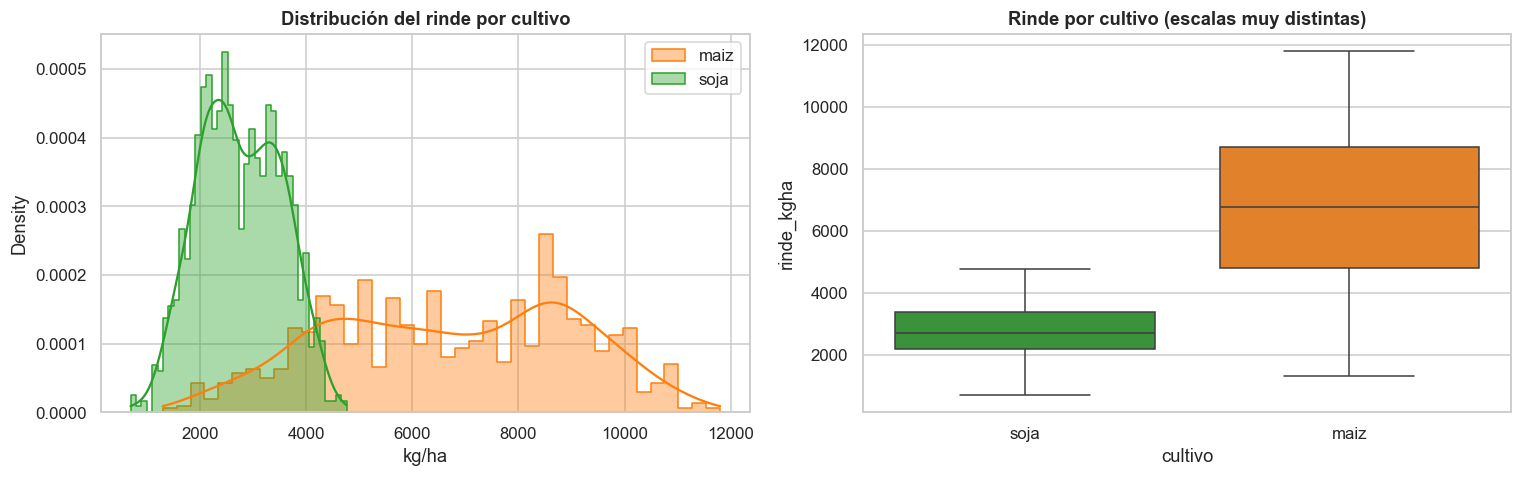

,count,mean,median,std,skew,min,max
cultivo,,,,,,,
maiz,1144,6718.2,6764.0,2319.6,-0.1,1300.0,11800.0
soja,1143,2760.5,2700.0,775.6,0.0,697.0,4764.0


In [37]:
# Distribución del rinde por cultivo
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for cult, g in df.groupby("cultivo"):
    sns.histplot(g[TARGET], bins=40, kde=True, ax=axes[0], label=cult,
                 color=CROP_COLORS[cult], element="step", stat="density", alpha=0.4)
axes[0].set_title("Distribución del rinde por cultivo")
axes[0].set_xlabel("kg/ha"); axes[0].legend()
sns.boxplot(data=df, x="cultivo", y=TARGET, hue="cultivo",
            palette=CROP_COLORS, ax=axes[1], legend=False)
axes[1].set_title("Rinde por cultivo (escalas muy distintas)")
plt.tight_layout(); plt.show()

display(df.groupby("cultivo")[TARGET].agg(["count", "mean", "median", "std", "skew", "min", "max"]).round(1))

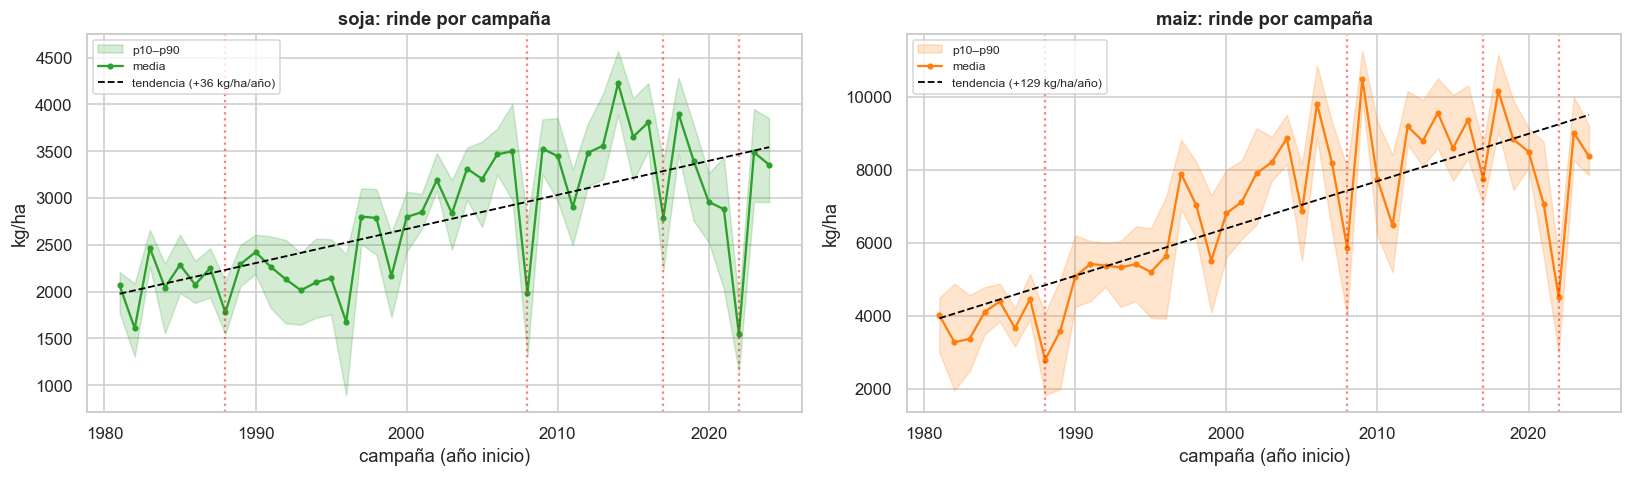

Líneas punteadas rojas = sequías conocidas. Tendencia ascendente = mejora tecnológica (no clima).


In [5]:
# Distribución y evolución temporal del rinde
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5), sharex=False)

# Evolución temporal
for ax, cult in zip(axes, ["soja", "maiz"]):
    g = df[df["cultivo"] == cult].groupby("campania_inicio")[TARGET]
    m, lo, hi = g.mean(), g.quantile(.1), g.quantile(.9)
    ax.fill_between(m.index, lo, hi, alpha=.2, color=CROP_COLORS[cult], label="p10–p90")
    ax.plot(m.index, m.values, marker="o", ms=3, color=CROP_COLORS[cult], label="media")
    z = np.polyfit(m.index, m.values, 1)
    ax.plot(m.index, np.poly1d(z)(m.index), "--", color="black", lw=1.2,
            label=f"tendencia (+{z[0]:.0f} kg/ha/año)")
    for y in SEQUIAS:
        ax.axvline(y, color="red", ls=":", alpha=.5)
    ax.set_title(f"{cult}: rinde por campaña")
    ax.set_xlabel("campaña (año inicio)"); ax.set_ylabel("kg/ha"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()
print("Líneas punteadas rojas = sequías conocidas. Tendencia ascendente = mejora tecnológica (no clima).")

### Anomalías de rinde (detrend)

Para separar la **variabilidad climática** de la **mejora tecnológica**, calculamos el residuo porcentual del rinde respecto de su tendencia lineal por cultivo. Las campañas con residuo muy negativo son las anómalas — el insumo para el componente de detección de anomalías del proyecto.

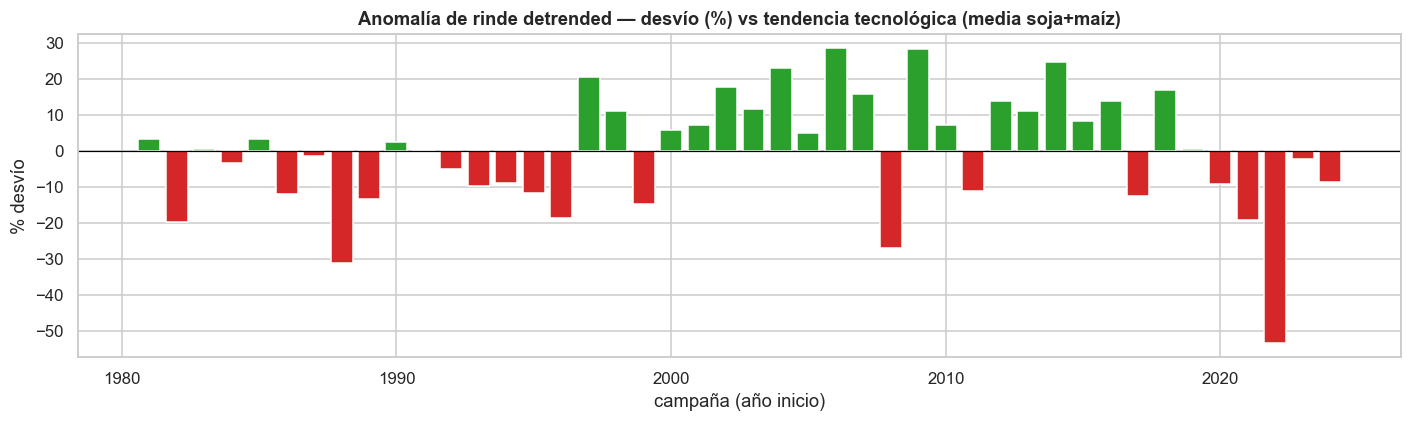

Peores campañas (desvío % vs tendencia):


campania_inicio
2022   -53.3
1988   -31.2
2008   -27.2
1982   -19.7
2021   -19.2
1996   -18.8
Name: _rinde_resid_pct, dtype: float64

In [6]:
# Anomalía de rinde = residuo vs tendencia lineal (separa clima de tecnología)
def detrend_residual(g):
    z = np.polyfit(g["campania_inicio"], g[TARGET], 1)
    pred = np.poly1d(z)(g["campania_inicio"])
    return (g[TARGET] - pred) / pred * 100

df["_rinde_resid_pct"] = df.groupby("cultivo", group_keys=False).apply(detrend_residual)

anom = df.groupby("campania_inicio")["_rinde_resid_pct"].mean().sort_index()
fig, ax = plt.subplots(figsize=(13, 4))
ax.bar(anom.index, anom.values,
       color=["#d62728" if v < 0 else "#2ca02c" for v in anom.values])
ax.axhline(0, color="black", lw=.8)
ax.set_title("Anomalía de rinde detrended — desvío (%) vs tendencia tecnológica (media soja+maíz)")
ax.set_xlabel("campaña (año inicio)"); ax.set_ylabel("% desvío")
plt.tight_layout(); plt.show()

print("Peores campañas (desvío % vs tendencia):"); display(anom.sort_values().head(6).round(1))

### 1.3 ONI / ENSO — driver climático global

El ONI es el principal predictor estacional conocido *antes* de la campaña. Se resume en un promedio Oct–Feb y se clasifica en fases La Niña / Neutro / El Niño.

> El efecto ENSO se mide sobre el **residuo detrended** para no confundir la señal climática con la mejora tecnológica.

ONI / ENSO (El Niño – La Niña)

El ONI es una serie **global** (igual para todos los deptos/cultivos de una campaña). Resumimos los 5 meses en un `_oni_mean` (Oct–Feb) y clasificamos cada campaña en La Niña (≤ −0.5), Neutro o El Niño (≥ +0.5). Es el principal driver climático *conocido de antemano*, así que su relación con el rinde es central para el pronóstico estacional.

> Para aislar el efecto climático de la tendencia tecnológica, el ENSO se compara contra el **residuo de rinde** (`_rinde_resid_pct`) calculado en la sección 3.

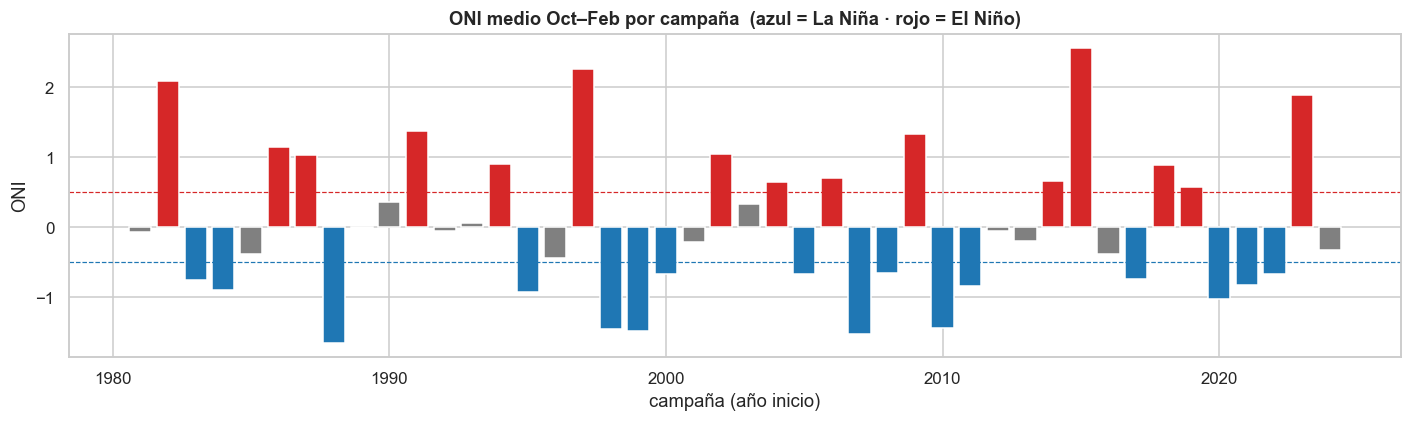

Campañas por fase ENSO: {'Nina': 16, 'Nino': 15, 'Neutro': 13}


In [7]:
# ONI medio Oct-Feb + clasificación ENSO
df["_oni_mean"] = df[ONI_COLS].mean(axis=1)
df["_enso"]     = pd.cut(df["_oni_mean"], [-np.inf, -0.5, 0.5, np.inf],
                         labels=["Nina", "Neutro", "Nino"]).astype(str)

oni_camp = df.groupby("campania_inicio")["_oni_mean"].first()
colors   = [ENSO_COLORS["Nina"] if v <= -0.5 else ENSO_COLORS["Nino"] if v >= 0.5
            else ENSO_COLORS["Neutro"] for v in oni_camp.values]

fig, ax = plt.subplots(figsize=(13, 4))
ax.bar(oni_camp.index, oni_camp.values, color=colors)
ax.axhline(0.5, color="#d62728", ls="--", lw=.8)
ax.axhline(-0.5, color="#1f77b4", ls="--", lw=.8)
ax.set_title("ONI medio Oct–Feb por campaña  (azul = La Niña · rojo = El Niño)")
ax.set_xlabel("campaña (año inicio)"); ax.set_ylabel("ONI")
plt.tight_layout(); plt.show()
print("Campañas por fase ENSO:", df.groupby("campania_inicio")["_enso"].first().value_counts().to_dict())

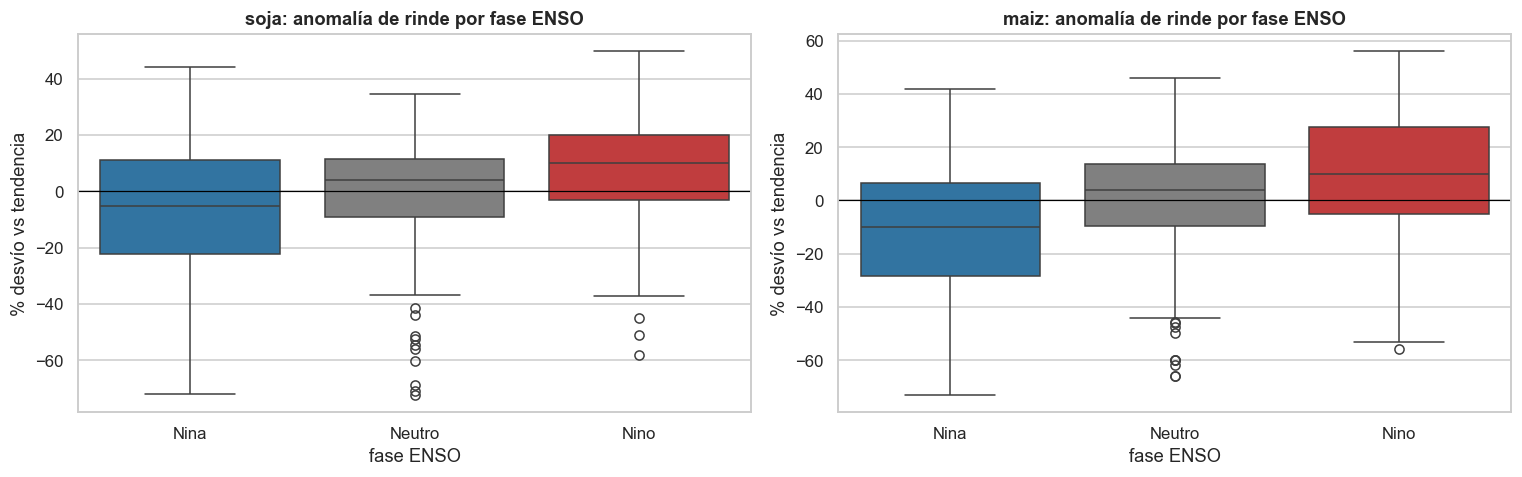

Anomalía media de rinde (%) por fase ENSO:


_enso,Neutro,Nina,Nino
cultivo,,,
maiz,1.5,-11.5,9.4
soja,0.2,-7.1,7.1


In [8]:
# Efecto ENSO sobre el rinde detrended
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for ax, cult in zip(axes, ["soja", "maiz"]):
    g = df[df["cultivo"] == cult]
    sns.boxplot(data=g, x="_enso", y="_rinde_resid_pct", order=["Nina", "Neutro", "Nino"],
                hue="_enso", palette=ENSO_COLORS, legend=False, ax=ax)
    ax.axhline(0, color="black", lw=.8)
    ax.set_title(f"{cult}: anomalía de rinde por fase ENSO")
    ax.set_xlabel("fase ENSO"); ax.set_ylabel("% desvío vs tendencia")
plt.tight_layout(); plt.show()

print("Anomalía media de rinde (%) por fase ENSO:")
display(df.groupby(["cultivo", "_enso"])["_rinde_resid_pct"].mean().round(1).unstack())

### 1.4 Proxy de pérdida de cosecha: % superficie cosechada/sembrada

El cociente cosechada/sembrada captura el abandono de lotes — una señal de campaña anómala complementaria al rinde, independiente de la tendencia tecnológica.

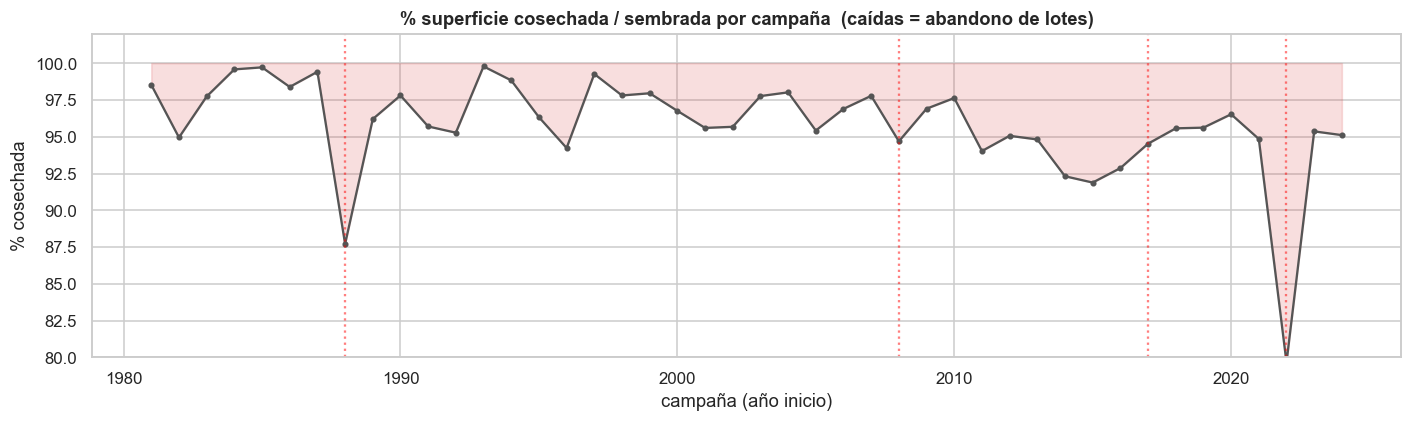

Campañas con más abandono (menor % cosechada):


campania_inicio
2022    79.6
1988    87.7
2015    91.9
2014    92.3
2016    92.9
Name: _pct_cosechada, dtype: float64

In [9]:
df["_pct_cosechada"] = df["sup_cosechada_ha"] / df["sup_sembrada_ha"] * 100
loss = df.groupby("campania_inicio")["_pct_cosechada"].mean()

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(loss.index, loss.values, marker="o", ms=3, color="#555")
ax.fill_between(loss.index, loss.values, 100, alpha=.15, color="#d62728")
for y in SEQUIAS:
    ax.axvline(y, color="red", ls=":", alpha=.5)
ax.set_title("% superficie cosechada / sembrada por campaña  (caídas = abandono de lotes)")
ax.set_xlabel("campaña (año inicio)"); ax.set_ylabel("% cosechada")
ax.set_ylim(80, 102)
plt.tight_layout(); plt.show()

print("Campañas con más abandono (menor % cosechada):"); display(loss.sort_values().head(5).round(1))

---
## 2. Ground truth proxy — etiquetado formal de campañas anómalas

El AE es no supervisado y no usa etiquetas en el entrenamiento. Sin embargo, necesitamos un etiquetado-proxy para:
1. **Excluir campañas anómalas del train del AE** (el AE aprende la distribución "normal").
2. **Medir la performance del detector** (ROC-AUC, PR-AUC) contra este ground truth.

**Criterio de etiquetado** — una fila (campaña × departamento × cultivo) es anómala si cumple *alguna* de:

| Criterio | Definición |
|---|---|
| `z_rinde < −1.5` | Rinde más de 1.5 desvíos por debajo de su media móvil de 5 años (ventana hacia atrás, sin leakage). |
| `oni_mean_octfeb ≤ −0.5` | Fase La Niña sostenida Oct–Feb (driver climático global). |

> **Nota sobre el criterio ONI:** es global (mismo valor en todos los departamentos de una campaña). Puede etiquetar como anómalos años Niña donde el rinde no cayó — esto se analiza en la sección siguiente.

In [10]:
# ── ONI medio Oct-Feb ─────────────────────────────────────────────────────
df["oni_mean_octfeb"] = df[ONI_COLS].mean(axis=1)

# ── Z-rinde: ventana móvil de 5 años hacia atrás, por departamento × cultivo ──
# shift(1): el año actual NO entra en su propia línea base (sin leakage)
# min_periods=3: necesita al menos 3 campañas previas; las primeras quedan NaN
df = df.sort_values(["departamento", "cultivo", "campania_inicio"]).reset_index(drop=True)
prev = df.groupby(["departamento", "cultivo"], sort=False)[TARGET].shift(1)
roll = prev.groupby([df["departamento"], df["cultivo"]], sort=False).rolling(5, min_periods=3)
df["rinde_roll_mean"] = roll.mean().reset_index(level=[0, 1], drop=True)
df["rinde_roll_std"]  = roll.std().reset_index(level=[0, 1], drop=True)
df["z_rinde"]         = (df[TARGET] - df["rinde_roll_mean"]) / df["rinde_roll_std"]

# ── Etiqueta booleana ──────────────────────────────────────────────────────
crit_z   = (df["z_rinde"] < -1.5).fillna(False)
crit_oni = df["oni_mean_octfeb"] <= -0.5
df["es_anomala"]    = crit_z | crit_oni
df["label_anomalia"] = np.where(df["es_anomala"], "anomala", "normal")

def fuente(z, o):
    if z and o: return "ambas"
    if z:       return "z_rinde"
    if o:       return "oni"
    return "normal"
df["fuente_anomalia"] = [fuente(z, o) for z, o in zip(crit_z, crit_oni)]

print(f"Filas anómalas: {df['es_anomala'].sum()} ({df['es_anomala'].mean()*100:.1f}%)")
print(df["fuente_anomalia"].value_counts().to_dict())

Filas anómalas: 885 (38.7%)
{'normal': 1402, 'oni': 595, 'ambas': 237, 'z_rinde': 53}


### 2.1 Distribución espaciotemporal de las anomalías

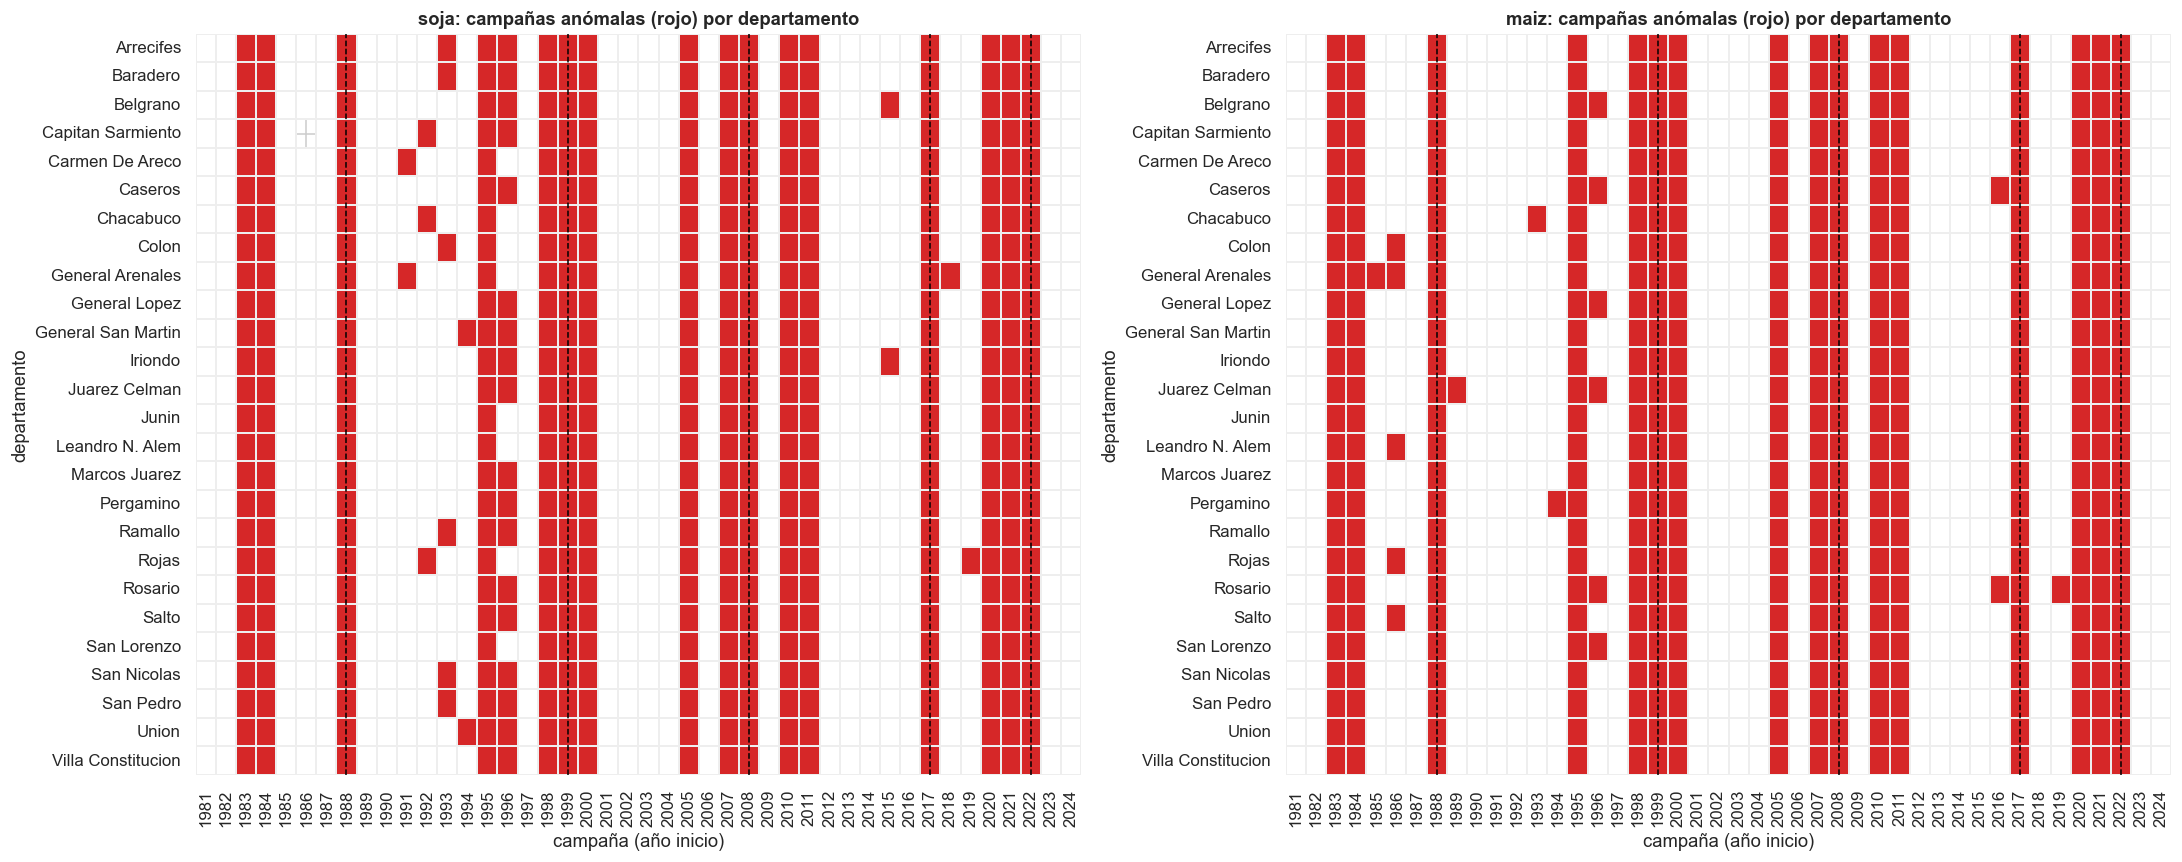

In [11]:
# Heatmap departamento × campaña: normal (blanco) vs anómala (rojo)
CAMP_CONOCIDAS = {1988: "1988/89", 1999: "1999/00", 2008: "2008/09", 2017: "2017/18", 2022: "2022/23"}

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
for ax, cult in zip(axes, ["soja", "maiz"]):
    piv = (df[df["cultivo"] == cult]
           .pivot_table(index="departamento", columns="campania_inicio",
                        values="es_anomala", aggfunc="max"))
    sns.heatmap(piv.astype(float), cmap=["white", ANOM_COLORS["anomala"]],
                vmin=0, vmax=1, cbar=False, linewidths=.3, linecolor="#eee", ax=ax)
    cols = list(piv.columns)
    for y, lab in CAMP_CONOCIDAS.items():
        if y in cols:
            ax.axvline(cols.index(y) + 0.5, color="black", ls="--", lw=1)
    ax.set_title(f"{cult}: campañas anómalas (rojo) por departamento")
    ax.set_xlabel("campaña (año inicio)"); ax.set_ylabel("departamento")
plt.tight_layout(); plt.show()

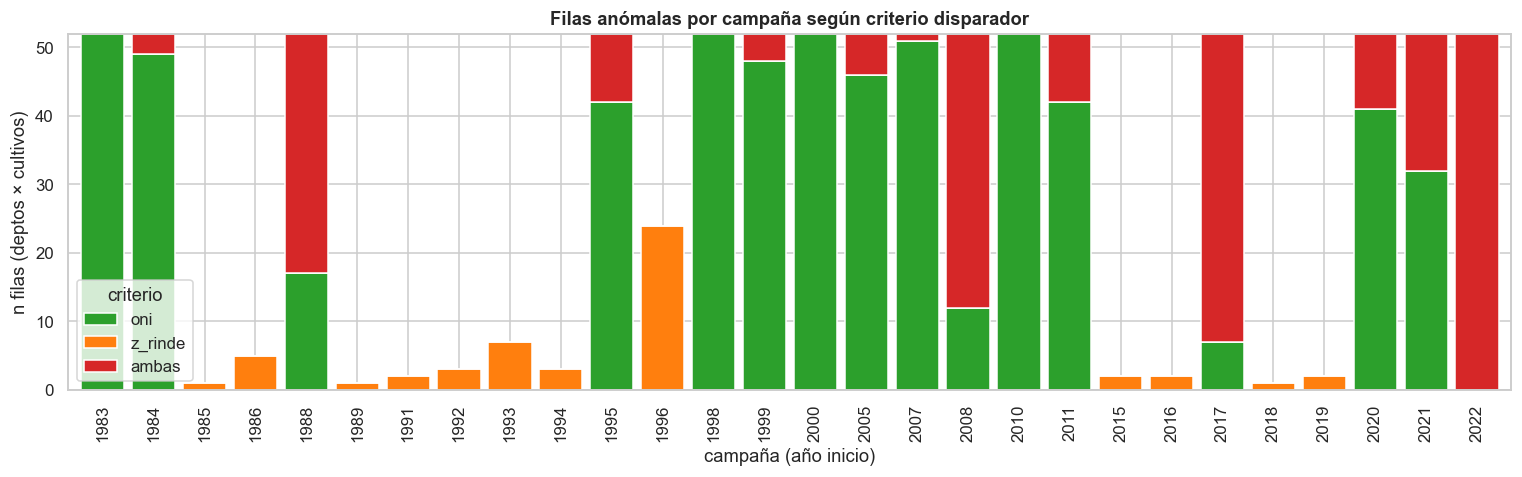

In [12]:
# Barplot apilado: filas anómalas por campaña, desglosado por criterio disparador
cnt = (df[df["es_anomala"]]
       .groupby(["campania_inicio", "fuente_anomalia"]).size()
       .unstack("fuente_anomalia", fill_value=0)
       .reindex(columns=["oni", "z_rinde", "ambas"], fill_value=0))
fuente_col = {"oni": "#2ca02c", "z_rinde": "#ff7f0e", "ambas": "#d62728"}

fig, ax = plt.subplots(figsize=(14, 4.5))
cnt.plot.bar(stacked=True, color=[fuente_col[c] for c in cnt.columns], ax=ax, width=.85)
ax.set_title("Filas anómalas por campaña según criterio disparador")
ax.set_xlabel("campaña (año inicio)"); ax.set_ylabel("n filas (deptos × cultivos)")
ax.legend(title="criterio")
plt.tight_layout(); plt.show()

> **Observación importante:** el criterio ONI es global y dominante — etiqueta años Niña con ONI fuerte aunque el rinde no haya caído (e.g. 2007: z_rinde = +0.41, 2010: z_rinde = 0.0). Esto afecta la especificidad del ground truth y se debe tener en cuenta al interpretar las métricas del AE. El criterio `z_rinde` captura el daño real al rinde.

In [13]:
# Tabla resumen: top 10 campañas más anómalas
resumen = (df.groupby("campania_inicio")
           .agg(n_anomalos=("es_anomala", "sum"),
                n_total=("es_anomala", "size"),
                oni_mean=("oni_mean_octfeb", "first"),
                z_rinde_mean=("z_rinde", "mean"))
           .assign(pct_anomalos=lambda t: (t["n_anomalos"] / t["n_total"] * 100).round(1))
           .sort_values("pct_anomalos", ascending=False))
print("Top 10 campañas más anómalas:")
display(resumen.head(10).round(2))

Top 10 campañas más anómalas:


,n_anomalos,n_total,oni_mean,z_rinde_mean,pct_anomalos
campania_inicio,,,,,
1984,52,52,-0.90,0.47,100.0
1983,52,52,-0.75,NaN,100.0
1988,52,52,-1.65,-2.13,100.0
2017,52,52,-0.74,-2.74,100.0
2010,52,52,-1.43,0.00,100.0
2007,52,52,-1.52,0.41,100.0
2005,52,52,-0.66,-0.12,100.0
2008,52,52,-0.65,-3.88,100.0
1998,52,52,-1.45,1.13,100.0


### 2.2 Definición del train set del AE

El AE se entrena **solo sobre campañas normales** dentro del split train. Se excluyen además las campañas train donde más del 30% de los departamentos son anómalos — esas campañas tienen señal climática atípica que el AE no debe aprender como "normal".

In [14]:
# Campañas de train con >30% deptos anómalos -> excluir del entrenamiento del AE
train_camp = df[df["split"] == "train"].groupby("campania_inicio")["es_anomala"].mean()
excluidas  = sorted(train_camp[train_camp > 0.30].index.tolist())

print("Campañas excluidas del train del AE (>30% deptos anómalos):")
print(" ", [f"{y}/{str(y+1)[-2:]}" for y in excluidas] or "ninguna")

n_train_normal = df[(df["split"] == "train") & (~df["es_anomala"])
                    & (~df["campania_inicio"].isin(excluidas))].shape[0]
print(f"\nFilas disponibles para el train del AE (normales, sin campañas excluidas): {n_train_normal}")

Campañas excluidas del train del AE (>30% deptos anómalos):
  ['1983/84', '1984/85', '1988/89', '1995/96', '1996/97', '1998/99', '1999/00', '2000/01', '2005/06', '2007/08', '2008/09', '2010/11', '2011/12', '2017/18']

Filas disponibles para el train del AE (normales, sin campañas excluidas): 1169


---
## 3. Espacio de features del AE

El AE recibe como input las **49 variables NASA POWER** (7 variables × 7 meses sep–mar) más el `oni_mean_octfeb`. Esta sección responde tres preguntas de diseño:

1. ¿Cuánta redundancia hay entre las features? → orienta el **tamaño del cuello de botella**.
2. ¿Cuánta dimensionalidad real existe? → orienta si conviene aplicar **PCA pre-AE**.
3. ¿Las campañas anómalas son distinguibles en este espacio? → valida la **factibilidad del detector**.

> Toda estadística (medias para imputación, PCA) se calcula solo sobre train.

In [15]:
# Función de escalado: z-score usando solo estadísticas de train
def escalar_con_train(cols):
    """z-score fit en train, transform en todo el panel. Imputa NaN con la media de train."""
    tr   = df.loc[df["split"] == "train", cols]
    mean = tr.mean(); std = tr.std().replace(0, 1)
    X    = (df[cols].fillna(mean) - mean) / std
    return X, mean, std

### 3.1 Correlación entre las 49 features NASA

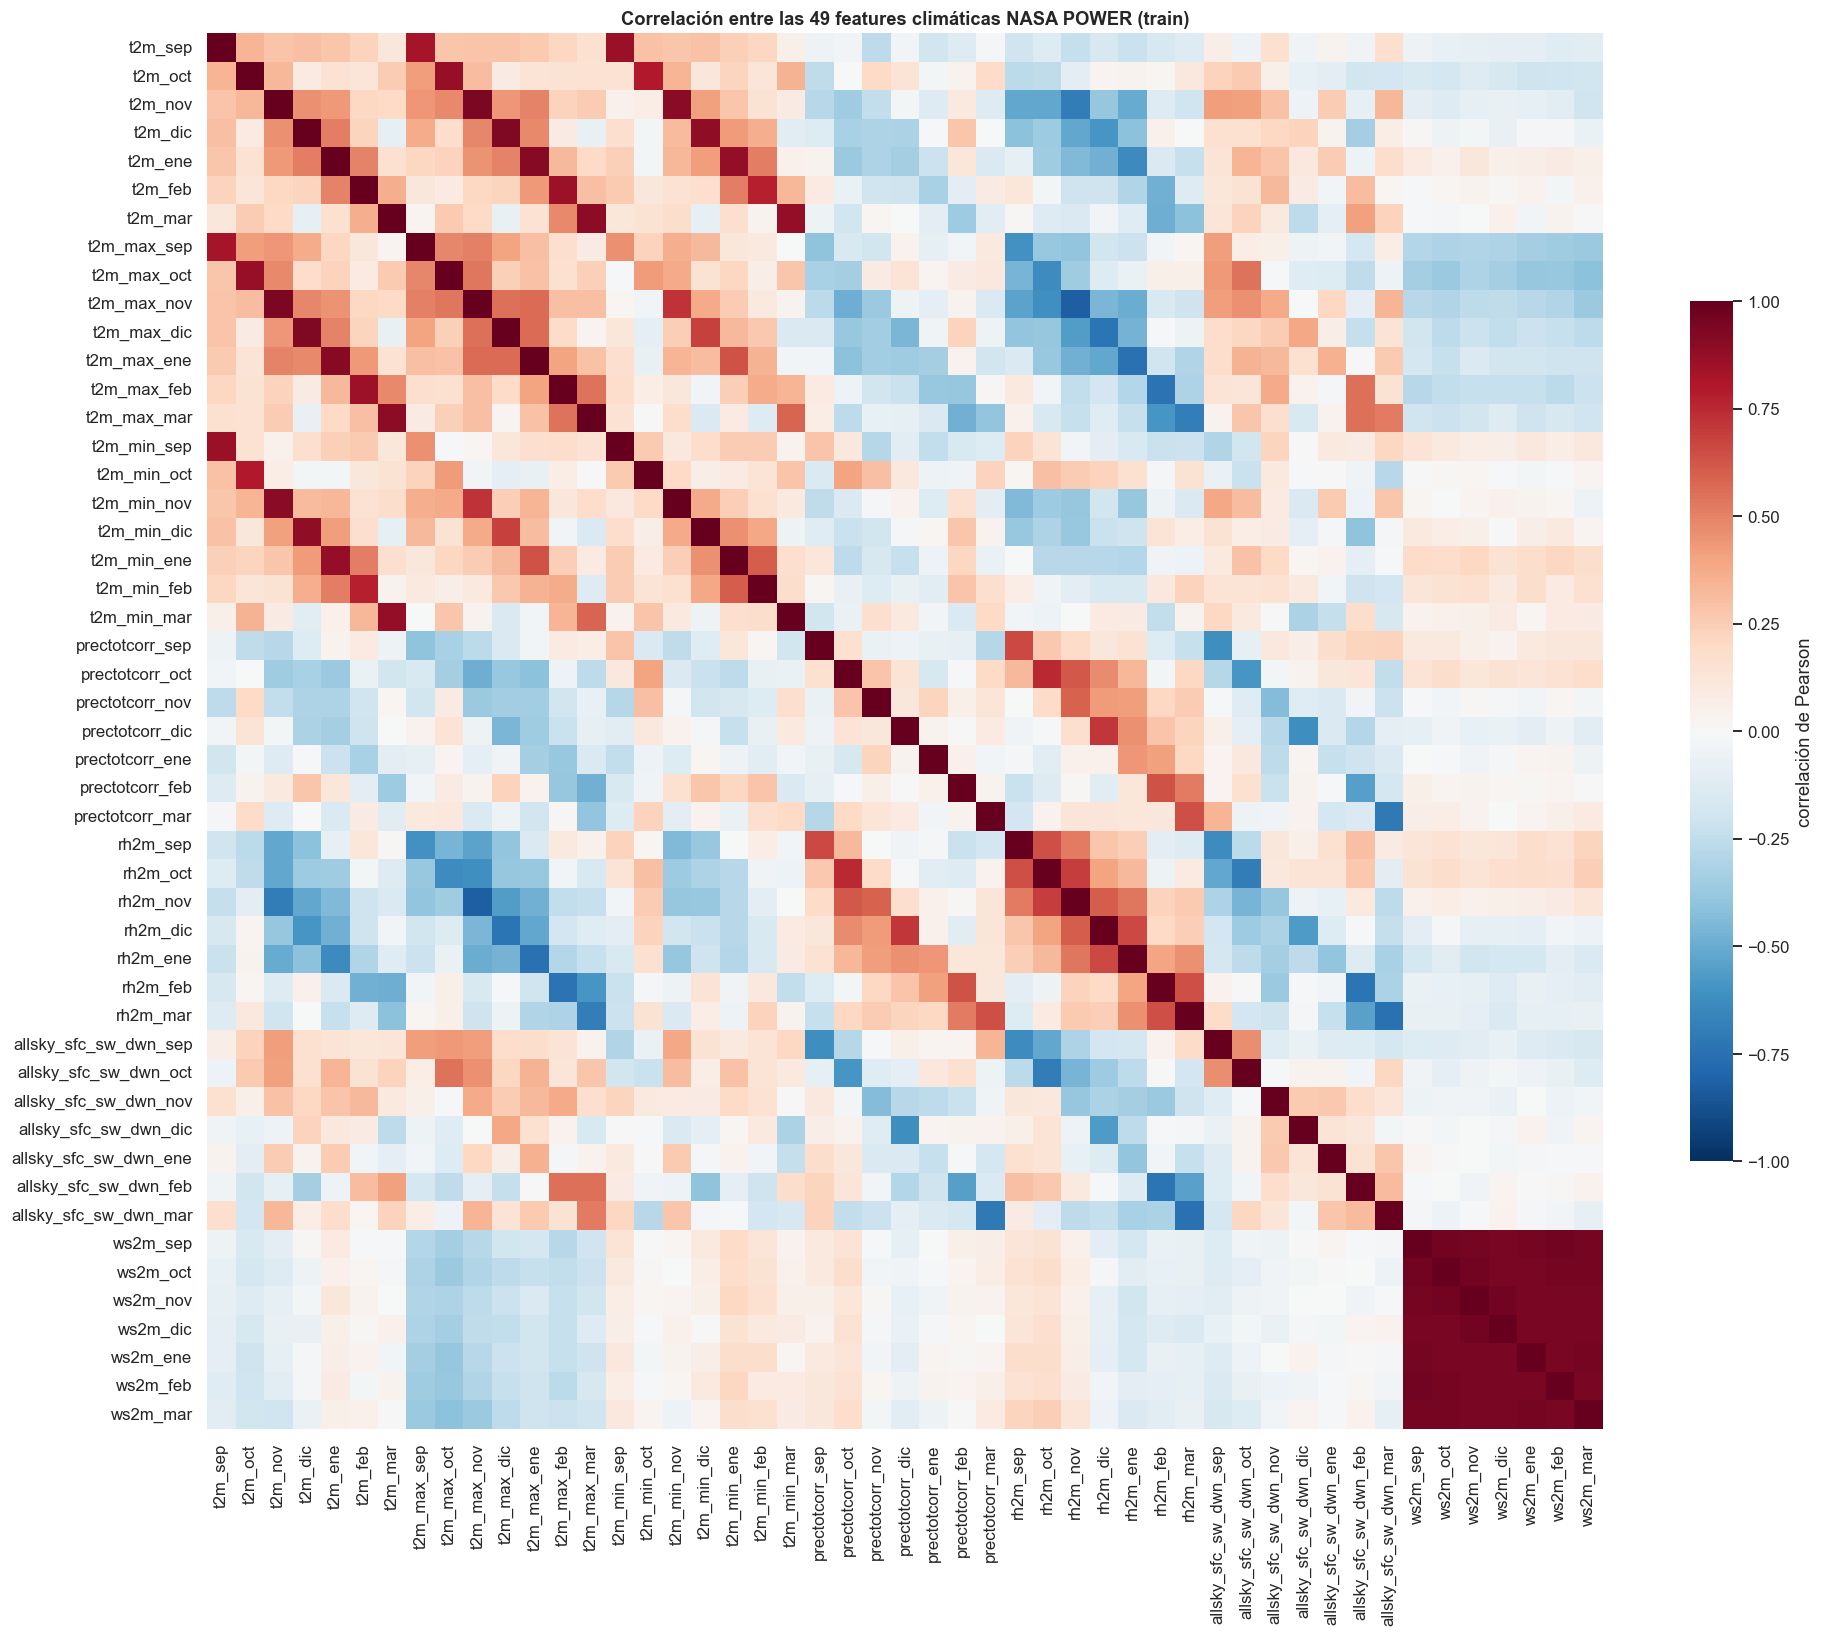

Top 10 pares con |corr| > 0.90:
  ws2m_oct                     ~ ws2m_nov                      r=0.966
  ws2m_sep                     ~ ws2m_feb                      r=0.966
  ws2m_sep                     ~ ws2m_oct                      r=0.963
  ws2m_nov                     ~ ws2m_dic                      r=0.962
  ws2m_oct                     ~ ws2m_feb                      r=0.960
  ws2m_ene                     ~ ws2m_mar                      r=0.960
  ws2m_sep                     ~ ws2m_mar                      r=0.958
  ws2m_oct                     ~ ws2m_mar                      r=0.958
  ws2m_sep                     ~ ws2m_nov                      r=0.957
  ws2m_sep                     ~ ws2m_ene                      r=0.957

Correlación |r| promedio INTRA-variable: 0.346
Correlación |r| promedio INTER-variable: 0.193


In [16]:
# Matriz de correlación (solo train, solo filas con rinde válido)
mask_tr = (df["split"] == "train") & df[TARGET].notna()
corr = df.loc[mask_tr, NASA_COLS].corr()

fig, ax = plt.subplots(figsize=(18, 15))
sns.heatmap(corr, cmap="RdBu_r", vmin=-1, vmax=1, square=True,
            cbar_kws={"shrink": .6, "label": "correlación de Pearson"}, ax=ax)
ax.set_title("Correlación entre las 49 features climáticas NASA POWER (train)")
plt.tight_layout(); plt.show()

# Redundancia extrema: pares con r > 0.90
cc    = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack()
altos = cc[cc > 0.90].sort_values(ascending=False)
print("Top 10 pares con |corr| > 0.90:")
for (a, b), v in altos.head(10).items():
    print(f"  {a:28s} ~ {b:28s}  r={v:.3f}")

# Correlación intra-variable vs inter-variable
def bloque(col): return col.rsplit("_", 1)[0]
bloques = {c: bloque(c) for c in NASA_COLS}
intra, inter = [], []
cm = corr.abs()
for i, a in enumerate(NASA_COLS):
    for b in NASA_COLS[i + 1:]:
        (intra if bloques[a] == bloques[b] else inter).append(cm.loc[a, b])
print(f"\nCorrelación |r| promedio INTRA-variable: {np.mean(intra):.3f}")
print(f"Correlación |r| promedio INTER-variable: {np.mean(inter):.3f}")

### 3.2 PCA: dimensionalidad real del espacio climático

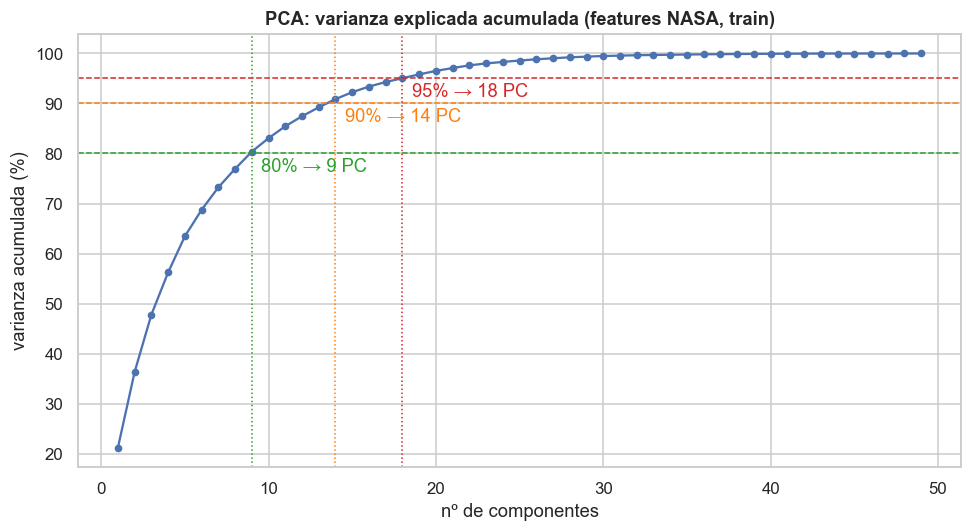

Componentes para 80/90/95% de varianza: 9 / 14 / 18
→ Cuello de botella sugerido para el AE: entre 7 y 14 neuronas.


In [17]:
X_nasa, _, _ = escalar_con_train(NASA_COLS)
X_nasa_train = X_nasa[df["split"] == "train"].values

pca_full = PCA(random_state=RANDOM_STATE).fit(X_nasa_train)
var_acum = np.cumsum(pca_full.explained_variance_ratio_) * 100
n80, n90, n95 = [int(np.argmax(var_acum >= t) + 1) for t in (80, 90, 95)]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(range(1, len(var_acum) + 1), var_acum, marker="o", ms=4)
for t, n, c in [(80, n80, "#2ca02c"), (90, n90, "#ff7f0e"), (95, n95, "#d62728")]:
    ax.axhline(t, color=c, ls="--", lw=1)
    ax.axvline(n, color=c, ls=":",  lw=1)
    ax.annotate(f"{t}% → {n} PC", (n, t), textcoords="offset points", xytext=(6, -12), color=c)
ax.set_title("PCA: varianza explicada acumulada (features NASA, train)")
ax.set_xlabel("nº de componentes"); ax.set_ylabel("varianza acumulada (%)")
plt.tight_layout(); plt.show()

print(f"Componentes para 80/90/95% de varianza: {n80} / {n90} / {n95}")
print(f"→ Cuello de botella sugerido para el AE: entre {n90//2} y {n90} neuronas.")

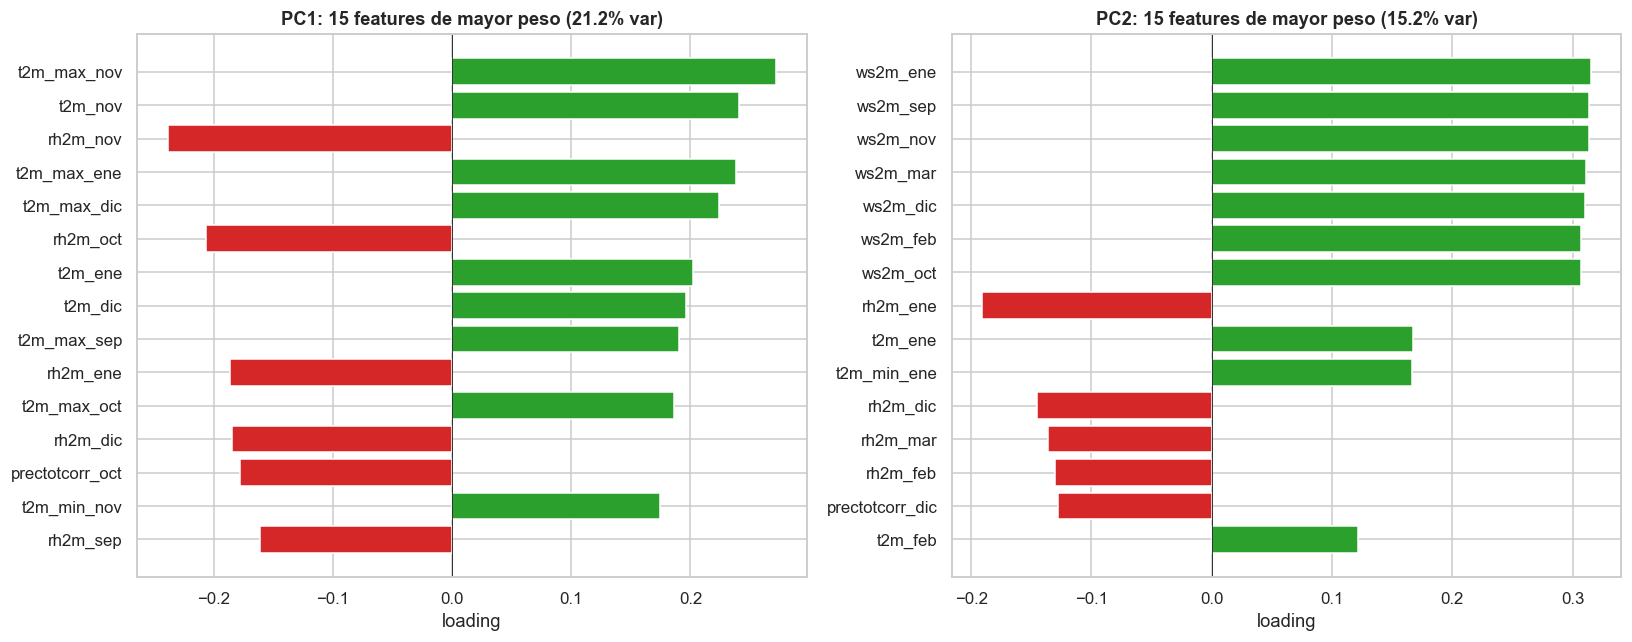

In [18]:
# Loadings PC1 y PC2: qué variables dominan cada componente (top 15 por |peso|)
load = pd.DataFrame(pca_full.components_[:2].T, index=NASA_COLS, columns=["PC1", "PC2"])
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, pc in zip(axes, ["PC1", "PC2"]):
    top = load[pc].reindex(load[pc].abs().sort_values(ascending=False).index).head(15)[::-1]
    ax.barh(top.index, top.values,
            color=["#d62728" if v < 0 else "#2ca02c" for v in top.values])
    idx = ["PC1", "PC2"].index(pc)
    ax.set_title(f"{pc}: 15 features de mayor peso "
                 f"({pca_full.explained_variance_ratio_[idx]*100:.1f}% var)")
    ax.set_xlabel("loading"); ax.axvline(0, color="black", lw=.5)
plt.tight_layout(); plt.show()

### 3.3 Separabilidad: ¿las anómalas difieren climáticamente de las normales?

Test de Mann-Whitney U (no paramétrico) para las 8 features más relevantes agronómicamente.

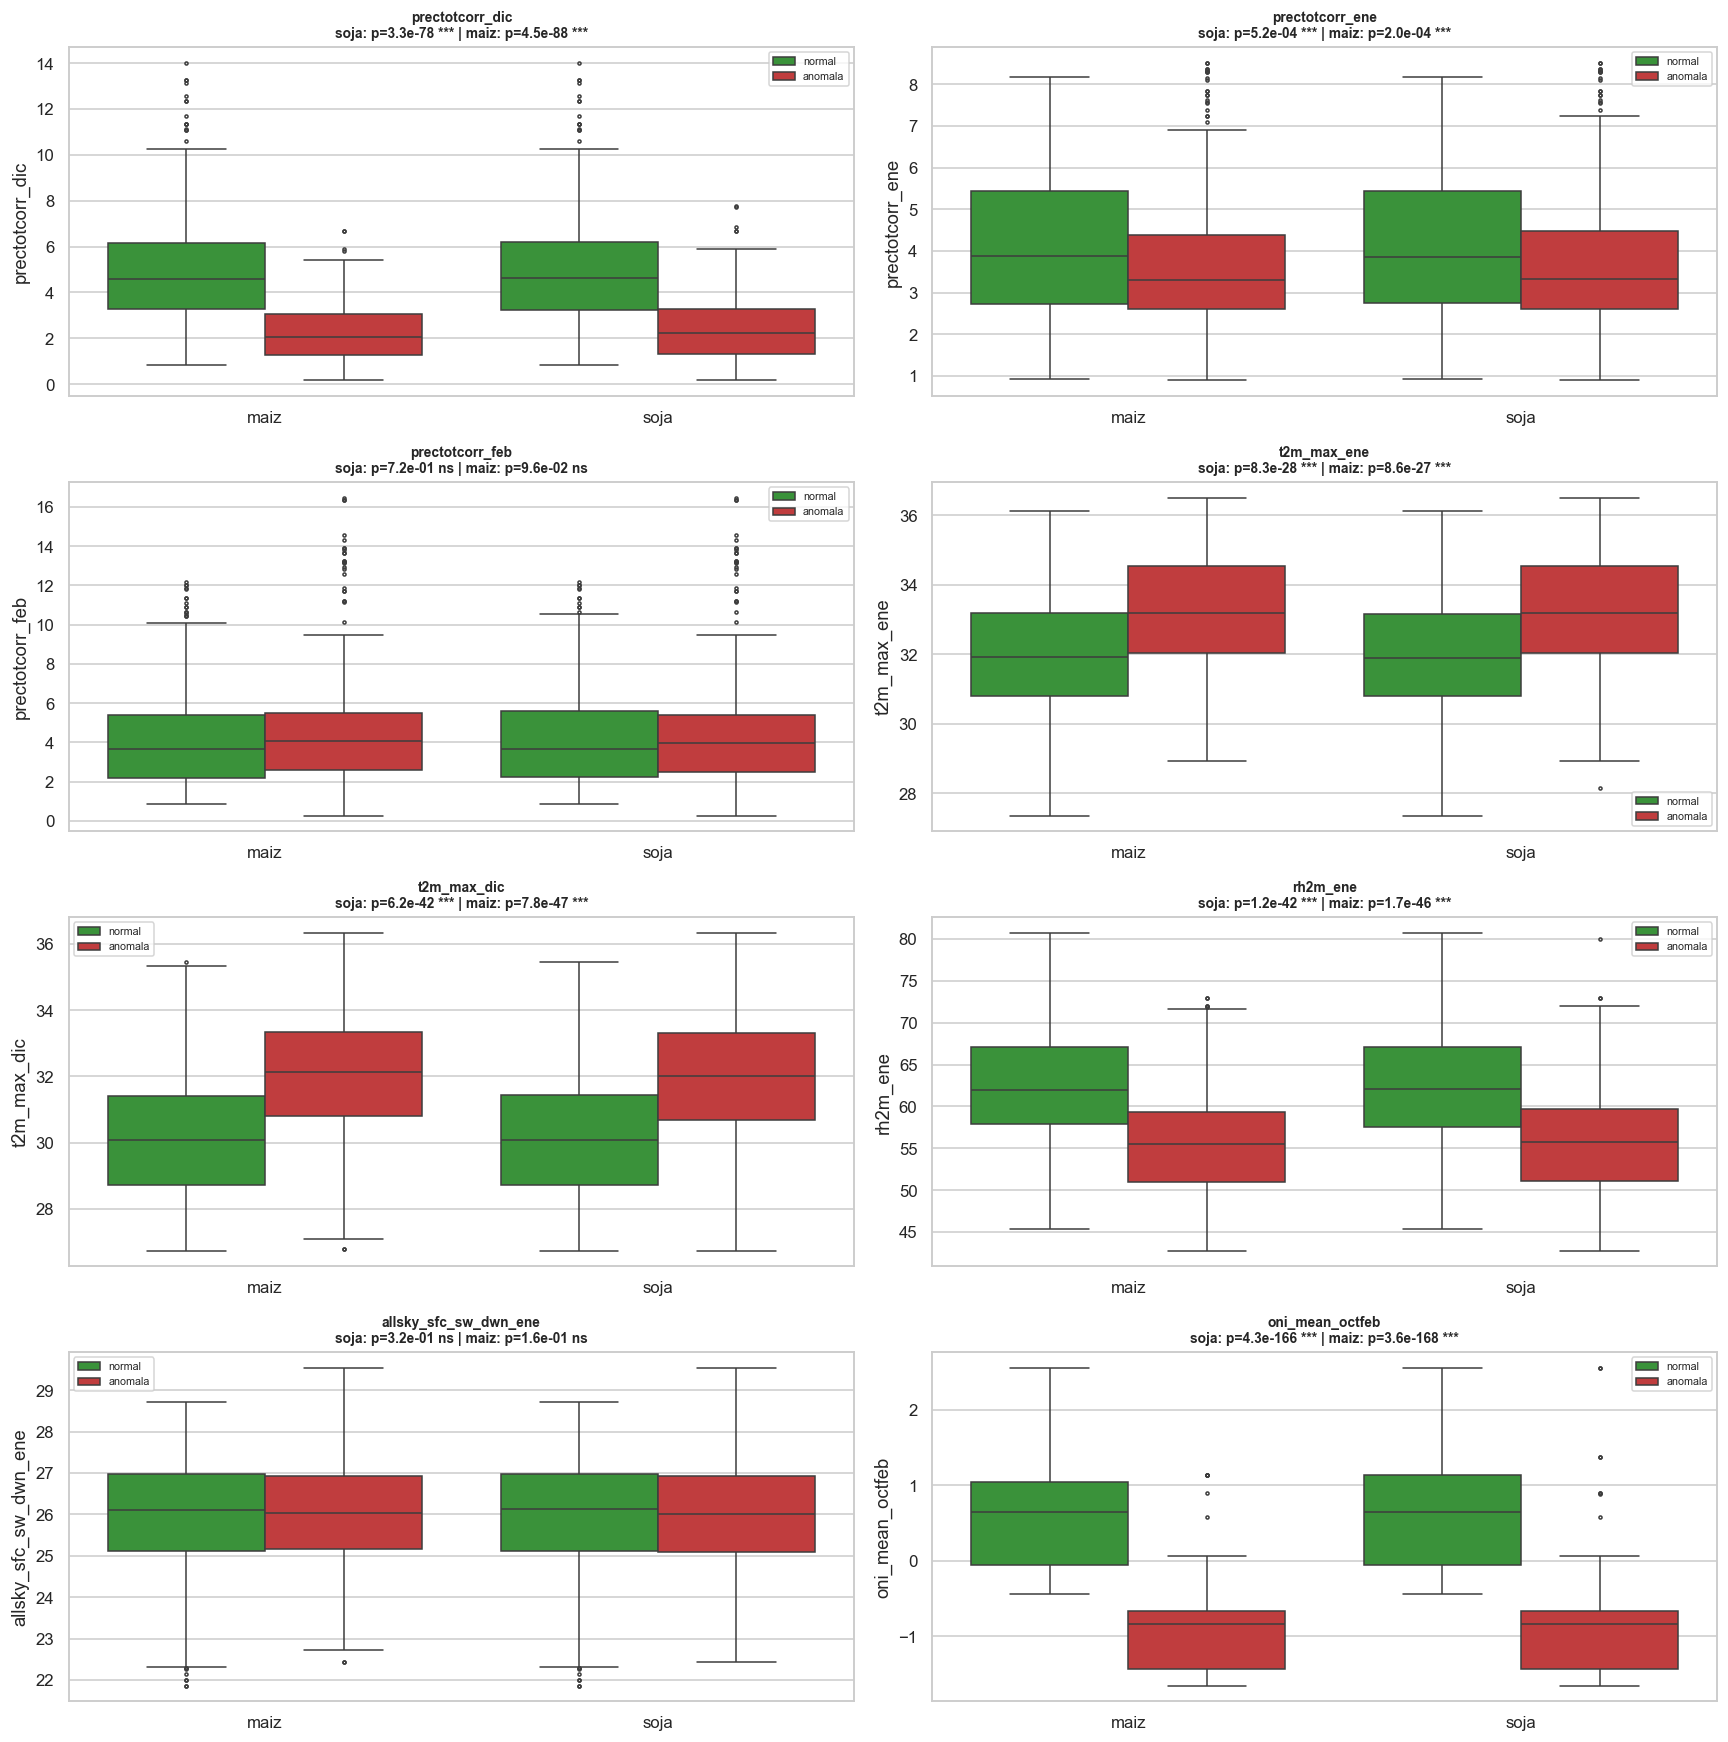

In [19]:
FEATS_CLAVE = ["prectotcorr_dic", "prectotcorr_ene", "prectotcorr_feb", "t2m_max_ene",
               "t2m_max_dic", "rh2m_ene", "allsky_sfc_sw_dwn_ene", "oni_mean_octfeb"]

def estrellas(p):
    return "***" if p < 1e-3 else "**" if p < 1e-2 else "*" if p < 0.05 else "ns"

fig, axes = plt.subplots(4, 2, figsize=(16, 16))
for ax, feat in zip(axes.ravel(), FEATS_CLAVE):
    sns.boxplot(data=df, x="cultivo", y=feat, hue="label_anomalia",
                hue_order=["normal", "anomala"], palette=ANOM_COLORS, ax=ax, fliersize=2)
    txt = []
    for cult in ["soja", "maiz"]:
        sub = df[df["cultivo"] == cult]
        a = sub.loc[sub["label_anomalia"] == "normal",  feat].dropna()
        b = sub.loc[sub["label_anomalia"] == "anomala", feat].dropna()
        if len(a) > 5 and len(b) > 5:
            p = mannwhitneyu(a, b).pvalue
            txt.append(f"{cult}: p={p:.1e} {estrellas(p)}")
    ax.set_title(f"{feat}\n" + " | ".join(txt), fontsize=9)
    ax.set_xlabel(""); ax.legend(fontsize=7, loc="best")
plt.tight_layout(); plt.show()

### 3.4 Perfiles mensuales: ¿cuándo diverge la señal climática?

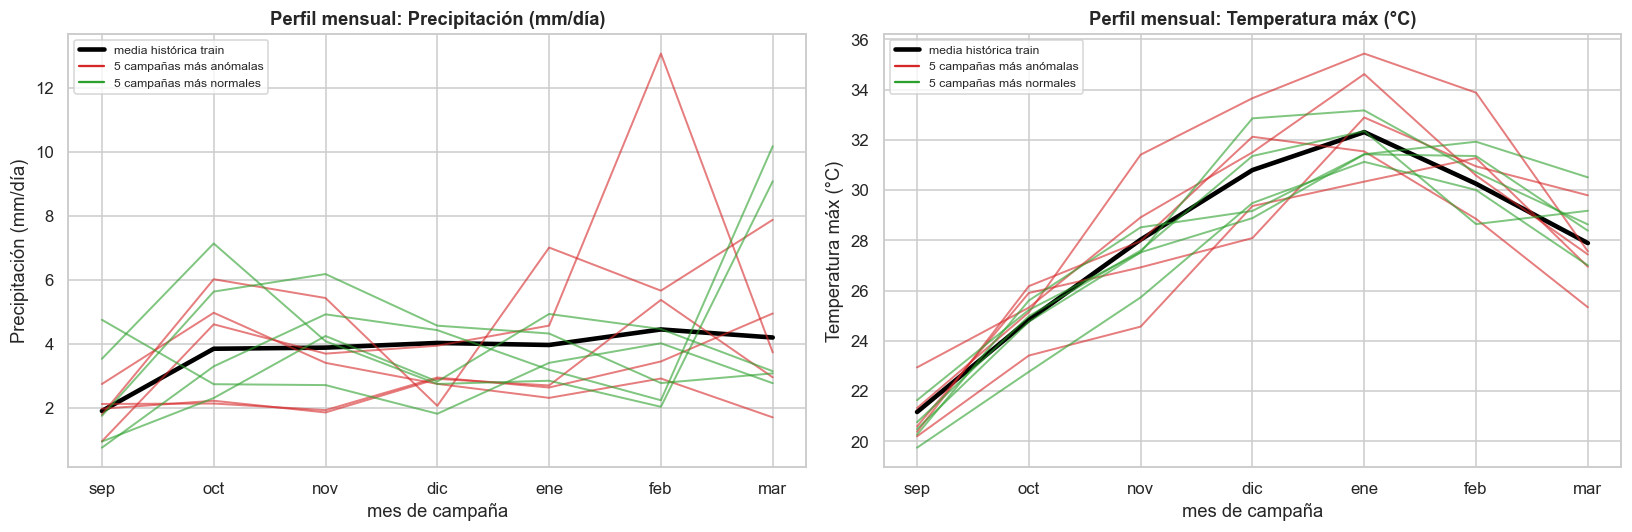

In [20]:
# 5 campañas más anómalas vs 5 más normales (train), promediando sobre todos los deptos
score_camp = df[df["split"] == "train"].groupby("campania_inicio")["es_anomala"].mean()
top_anom   = score_camp.sort_values(ascending=False).head(5).index.tolist()
top_norm   = score_camp.sort_values().head(5).index.tolist()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, (var, label) in zip(axes, [("prectotcorr", "Precipitación (mm/día)"),
                                    ("t2m_max", "Temperatura máx (°C)")]):
    cols_var = nasa_var_cols(var)
    hist = df[df["split"] == "train"][cols_var].mean()
    ax.plot(MESES, hist.values, color="black", lw=3, label="media histórica train")
    for y in top_anom:
        s = df[df["campania_inicio"] == y][cols_var].mean()
        ax.plot(MESES, s.values, color="#d62728", alpha=.6, lw=1.3)
    for y in top_norm:
        s = df[df["campania_inicio"] == y][cols_var].mean()
        ax.plot(MESES, s.values, color="#2ca02c", alpha=.6, lw=1.3)
    ax.plot([], [], color="#d62728", label="5 campañas más anómalas")
    ax.plot([], [], color="#2ca02c", label="5 campañas más normales")
    ax.set_title(f"Perfil mensual: {label}")
    ax.set_xlabel("mes de campaña"); ax.set_ylabel(label); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

---
## 4. Proyecciones 2D del espacio climático

Reducción de dimensionalidad para validar visualmente la separabilidad normal/anómala y detectar posible distribution shift entre splits.

**Input:** 49 features NASA + `oni_mean_octfeb`, normalizadas con z-score de train.  
**Colores:** verde = normal · rojo = anómala. **Marcadores:** círculo = soja · triángulo = maíz.

> t-SNE es estocástico y no preserva distancias globales. Usarlo solo para exploración visual, no para medir separabilidad.

In [21]:
# Preparación común para las tres proyecciones
FEAT_PROJ = NASA_COLS + ["oni_mean_octfeb"]
X_proj, _, _ = escalar_con_train(FEAT_PROJ)

is_tr   = (df["split"] == "train").values
Xtr     = X_proj[is_tr].values
lab_tr  = df.loc[is_tr, "label_anomalia"].values
crop_tr = df.loc[is_tr, "cultivo"].values
camp_tr = df.loc[is_tr, "campania_inicio"].values

MARCADOR     = {"soja": "o", "maiz": "^"}
CAMP_EXTREMAS = [1988, 1999, 2008, 2017]

def scatter_2d(ax, emb, labels, crops, title):
    for cult in ["soja", "maiz"]:
        for lab in ["normal", "anomala"]:
            m = (crops == cult) & (labels == lab)
            ax.scatter(emb[m, 0], emb[m, 1], s=18, alpha=.6,
                       c=ANOM_COLORS[lab], marker=MARCADOR[cult],
                       label=f"{cult}-{lab}", edgecolors="none")
    ax.set_title(title); ax.set_xlabel("dim 1"); ax.set_ylabel("dim 2")

def anotar_campanas(ax, emb, camp):
    for y in CAMP_EXTREMAS:
        m = camp == y
        if m.any():
            cx, cy = emb[m, 0].mean(), emb[m, 1].mean()
            ax.annotate(f"{y}/{str(y+1)[-2:]}", (cx, cy), fontsize=8, fontweight="bold",
                        bbox=dict(boxstyle="round,pad=0.2", fc="yellow", alpha=.7))

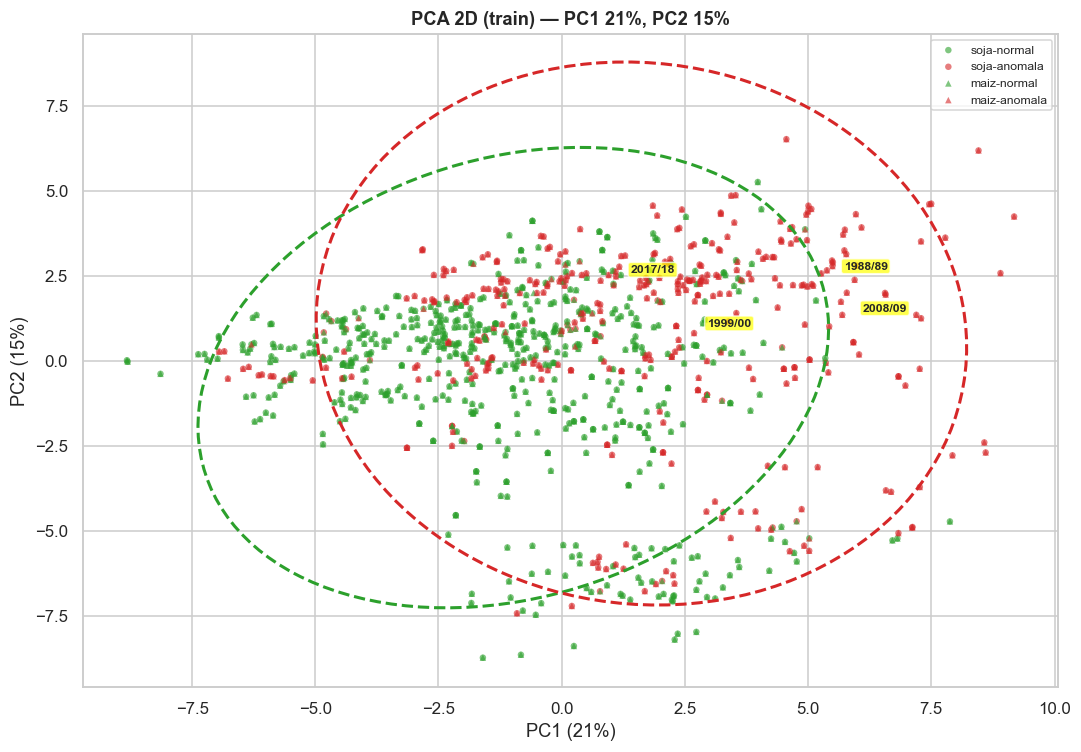

In [22]:
# PCA 2D con elipses de confianza 95%
def elipse_confianza(ax, x, y, color, n_std=2.4477):  # chi2 95%, 2 gl
    cov  = np.cov(x, y)
    vals, vecs = np.linalg.eigh(cov)
    ang  = np.degrees(np.arctan2(*vecs[:, 1][::-1]))
    w, h = 2 * n_std * np.sqrt(vals)
    e = Ellipse((x.mean(), y.mean()), w, h, angle=ang, fc="none", ec=color, lw=2, ls="--")
    ax.add_patch(e)

pca2    = PCA(n_components=2, random_state=RANDOM_STATE).fit(Xtr)
emb_pca = pca2.transform(Xtr)
vr      = pca2.explained_variance_ratio_ * 100

fig, ax = plt.subplots(figsize=(10, 7))
scatter_2d(ax, emb_pca, lab_tr, crop_tr, f"PCA 2D (train) — PC1 {vr[0]:.0f}%, PC2 {vr[1]:.0f}%")
for lab in ["normal", "anomala"]:
    m = lab_tr == lab
    elipse_confianza(ax, emb_pca[m, 0], emb_pca[m, 1], ANOM_COLORS[lab])
anotar_campanas(ax, emb_pca, camp_tr)
ax.set_xlabel(f"PC1 ({vr[0]:.0f}%)"); ax.set_ylabel(f"PC2 ({vr[1]:.0f}%)")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

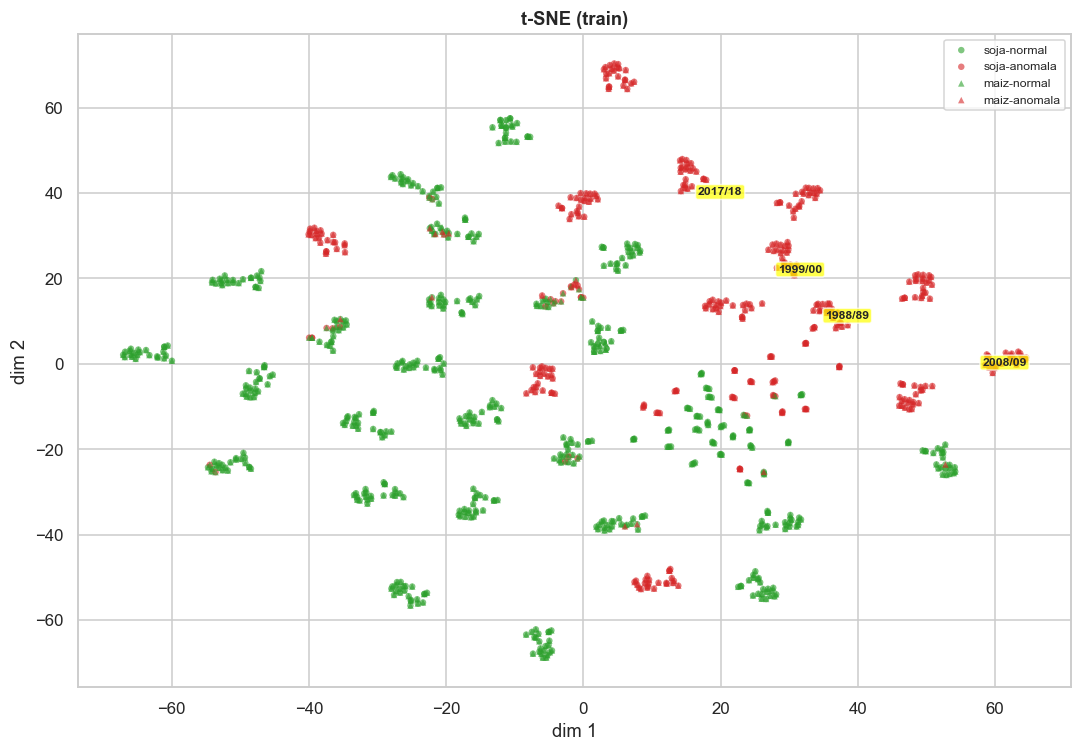

In [23]:
# t-SNE (solo train)
tsne     = TSNE(n_components=2, perplexity=30, max_iter=1000, random_state=RANDOM_STATE, init="pca")
emb_tsne = tsne.fit_transform(Xtr)

fig, ax = plt.subplots(figsize=(10, 7))
scatter_2d(ax, emb_tsne, lab_tr, crop_tr, "t-SNE (train)")
anotar_campanas(ax, emb_tsne, camp_tr)
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

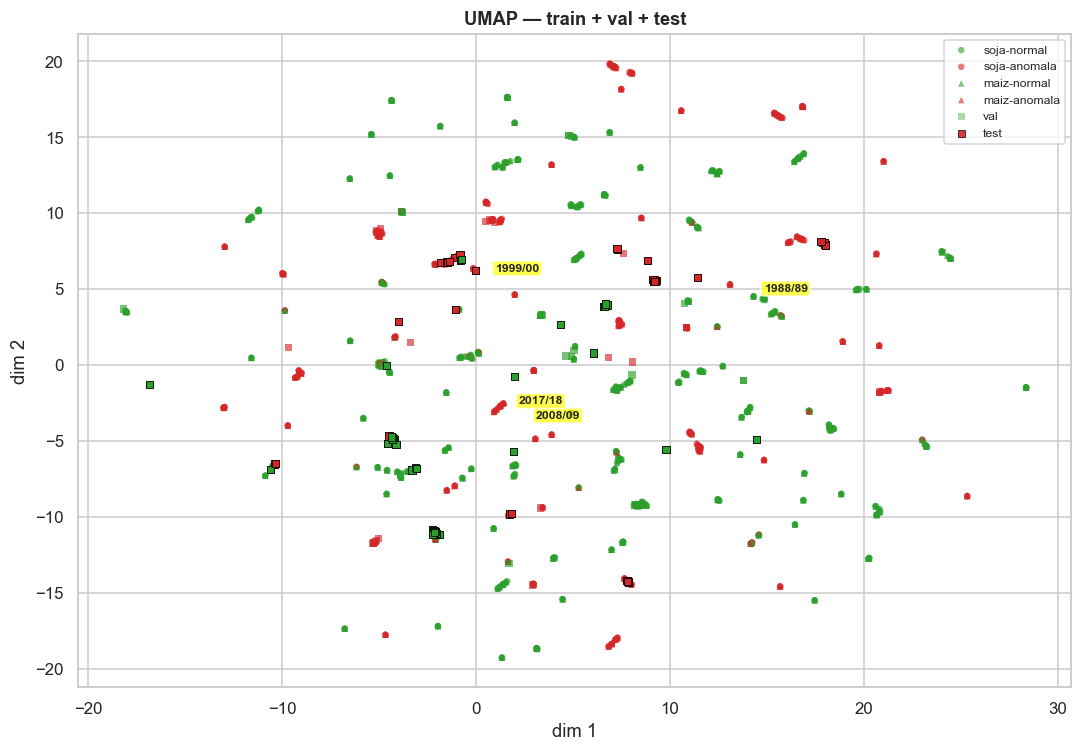

Cuadrados = val (transparente) y test (borde negro). Sin shift visible → el AE generaliza dentro del espacio conocido.


In [24]:
# UMAP: fit en train, transform en val y test (distribution shift)
reducer     = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=RANDOM_STATE)
emb_umap_tr = reducer.fit_transform(Xtr)

fig, ax = plt.subplots(figsize=(10, 7))
scatter_2d(ax, emb_umap_tr, lab_tr, crop_tr, "UMAP — train + val + test")
anotar_campanas(ax, emb_umap_tr, camp_tr)
for split, alpha, edge in [("val", 0.4, "none"), ("test", 0.9, "black")]:
    m    = (df["split"] == split).values
    emb  = reducer.transform(X_proj[m].values)
    cols = df.loc[m, "label_anomalia"].map(ANOM_COLORS).values
    ax.scatter(emb[:, 0], emb[:, 1], s=22, alpha=alpha, c=cols,
               edgecolors=edge, linewidths=.5, marker="s", label=split)
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()
print("Cuadrados = val (transparente) y test (borde negro). Sin shift visible → el AE generaliza dentro del espacio conocido.")

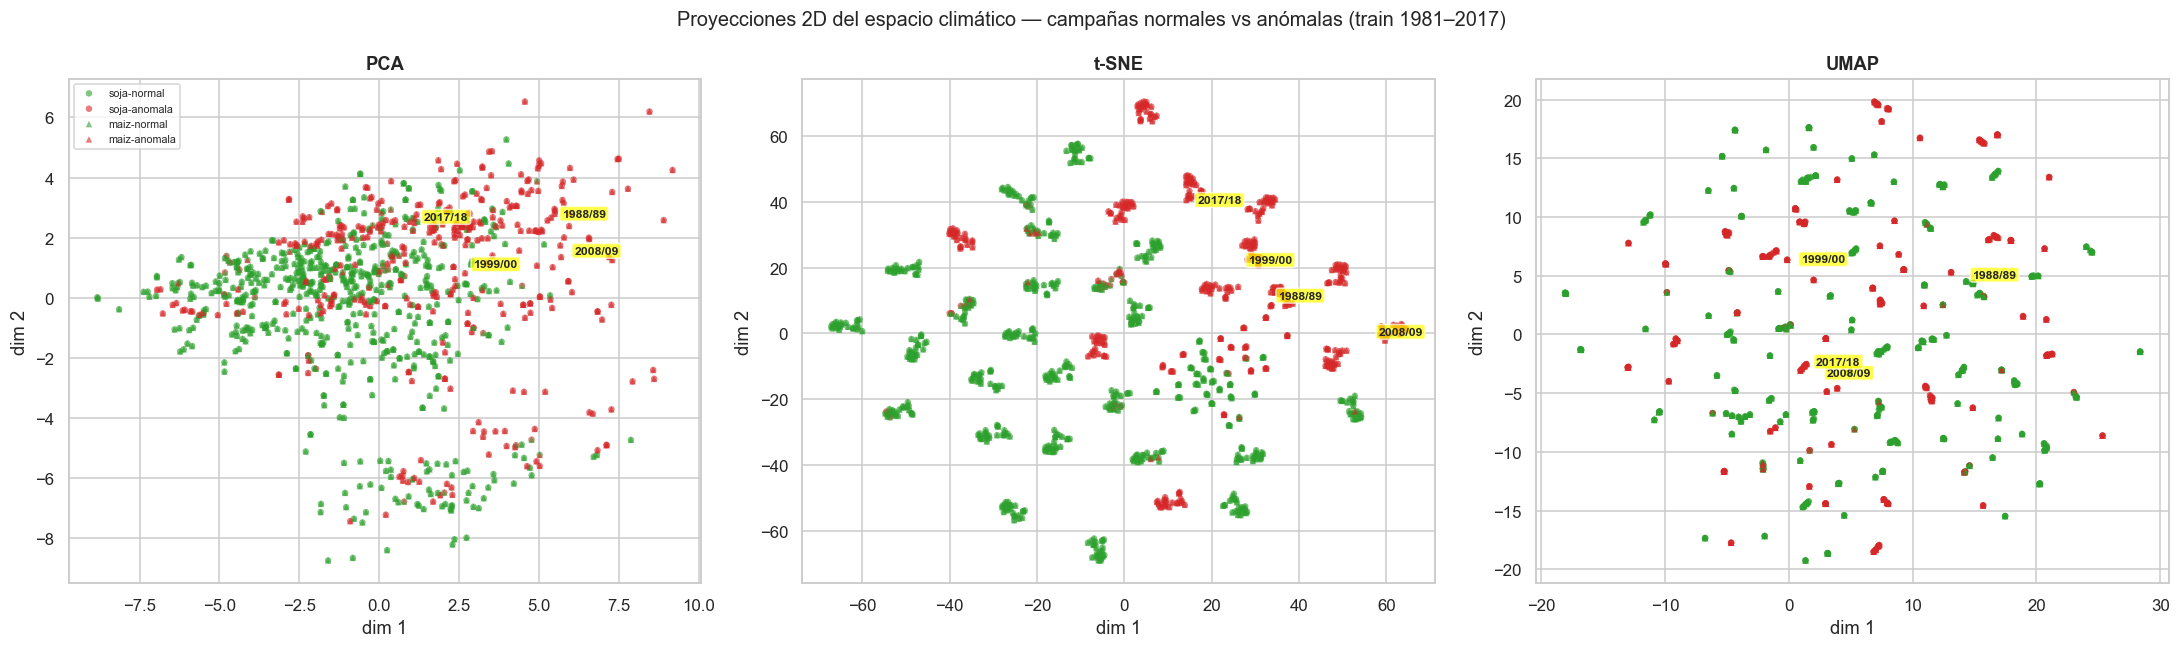

In [25]:
# Panel comparativo: PCA · t-SNE · UMAP (solo train)
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for ax, emb, name in [(axes[0], emb_pca, "PCA"),
                       (axes[1], emb_tsne, "t-SNE"),
                       (axes[2], emb_umap_tr, "UMAP")]:
    scatter_2d(ax, emb, lab_tr, crop_tr, name)
    anotar_campanas(ax, emb, camp_tr)
axes[0].legend(fontsize=7)
fig.suptitle("Proyecciones 2D del espacio climático — campañas normales vs anómalas (train 1981–2017)",
             fontsize=13)
plt.tight_layout(); plt.show()

---
## 5. Variabilidad departamental — justificación de la normalización por departamento

Si la diferencia climática **estructural entre departamentos** es comparable a la variabilidad **interanual dentro de un departamento**, una normalización global mezclaría la firma climática del lugar con la anomalía de campaña. El AE identificaría a un departamento naturalmente seco como "anómalo" cuando simplemente es seco por su geografía.

prectotcorr_ene: variación ENTRE deptos = 0.59 mm/día | variación interanual DENTRO de un depto = 1.64 mm/día
t2m_max_ene: variación ENTRE deptos = 2.63 °C | variación interanual DENTRO de un depto = 1.57 °C


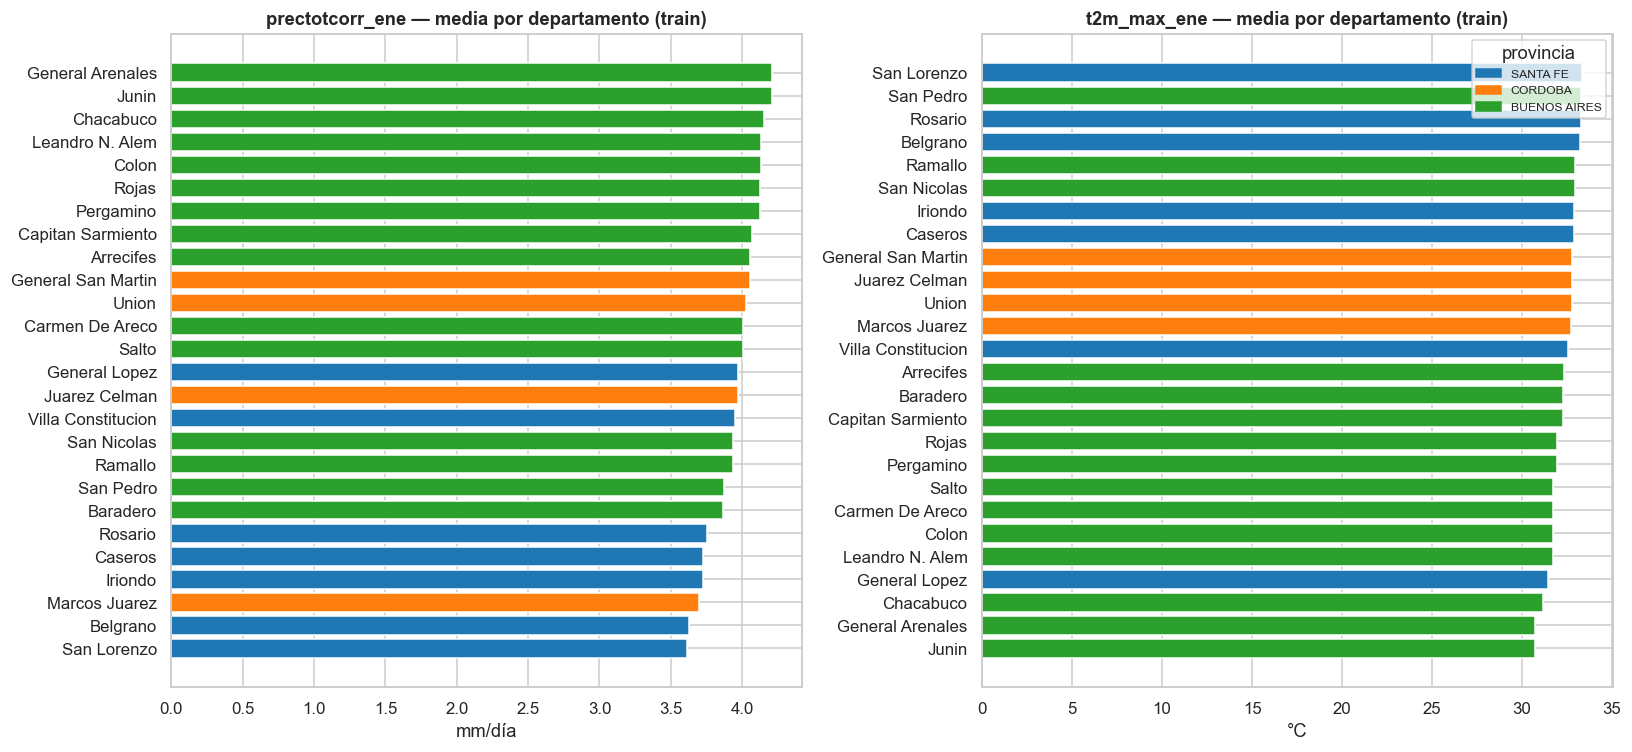


Si variación entre deptos ≥ variación interanual → normalizar por departamento, no globalmente.


In [26]:
tr = df[df["split"] == "train"]
fig, axes = plt.subplots(1, 2, figsize=(15, 7))
for ax, (feat, unidad) in zip(axes, [("prectotcorr_ene", "mm/día"), ("t2m_max_ene", "°C")]):
    medias = tr.groupby(["departamento", "provincia"])[feat].mean().reset_index().sort_values(feat)
    ax.barh(medias["departamento"], medias[feat],
            color=[PROV_COLORS.get(p, "#888") for p in medias["provincia"]])
    ax.set_title(f"{feat} — media por departamento (train)")
    ax.set_xlabel(unidad)
    entre = medias[feat].max() - medias[feat].min()
    intra = tr.groupby("departamento")[feat].std().mean()
    print(f"{feat}: variación ENTRE deptos = {entre:.2f} {unidad} | variación interanual DENTRO de un depto = {intra:.2f} {unidad}")

handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in PROV_COLORS.values()]
axes[1].legend(handles, PROV_COLORS.keys(), title="provincia", fontsize=8)
plt.tight_layout(); plt.show()
print("\nSi variación entre deptos ≥ variación interanual → normalizar por departamento, no globalmente.")

### 5.1 Heterogeneidad de la señal clima–rinde por departamento

La correlación clima-rinde varía por departamento y cultivo, lo que orienta qué variables serán las más sensibles al error de reconstrucción del AE.

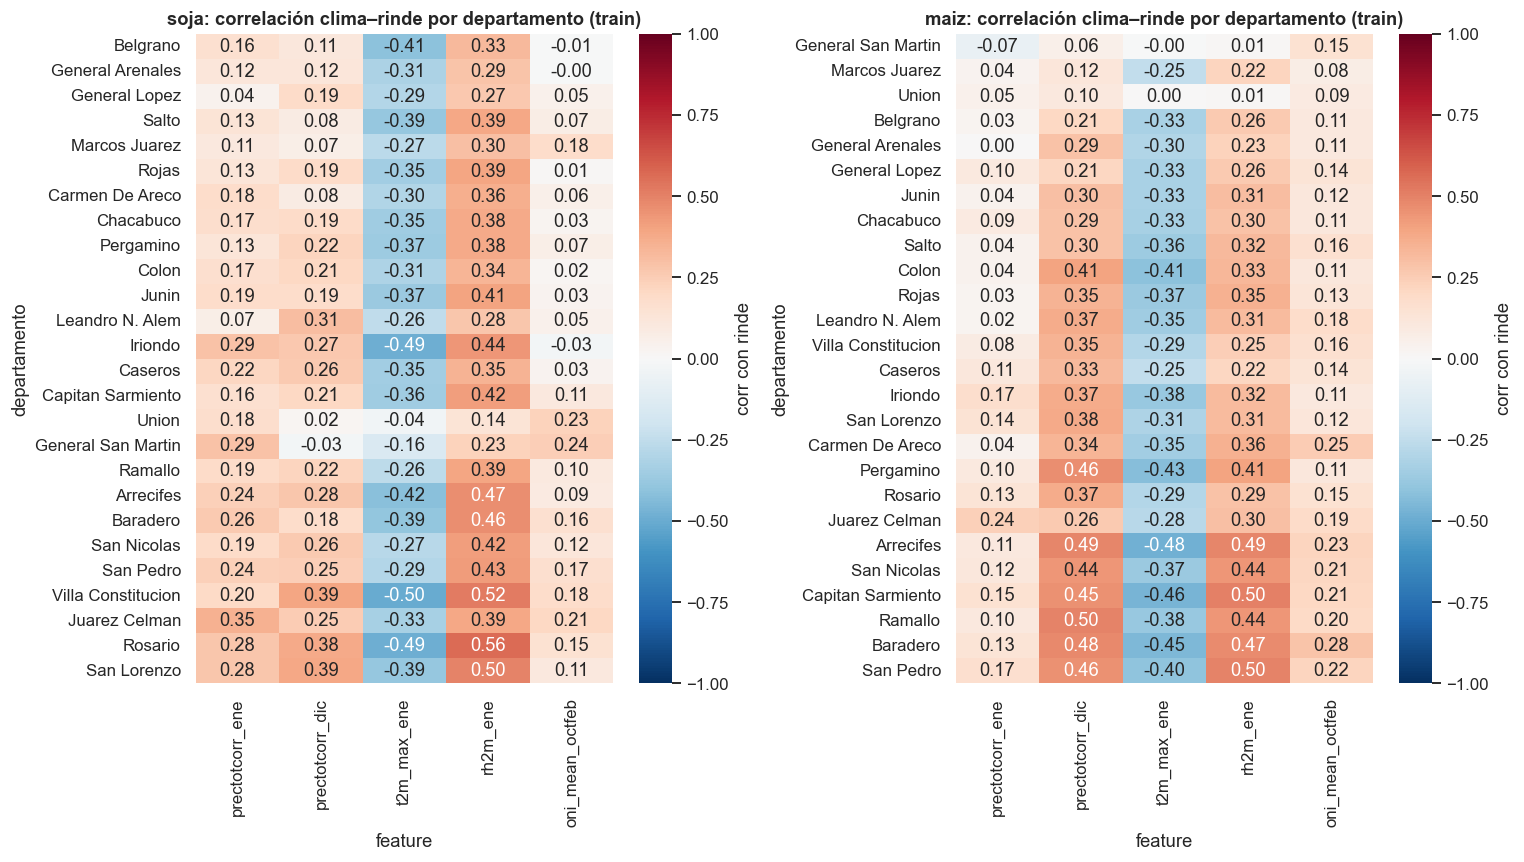

In [27]:
FEATS_CORR = ["prectotcorr_ene", "prectotcorr_dic", "t2m_max_ene", "rh2m_ene", "oni_mean_octfeb"]

fig, axes = plt.subplots(1, 2, figsize=(14, 8))
for ax, cult in zip(axes, ["soja", "maiz"]):
    sub = df[(df["split"] == "train") & (df["cultivo"] == cult)]
    filas = {}
    for dep, g in sub.groupby("departamento"):
        filas[dep] = [g[[f, TARGET]].corr().iloc[0, 1] for f in FEATS_CORR]
    cmat = pd.DataFrame(filas, index=FEATS_CORR).T
    cmat = cmat.loc[cmat.mean(axis=1).sort_values().index]
    sns.heatmap(cmat, cmap="RdBu_r", center=0, vmin=-1, vmax=1,
                annot=True, fmt=".2f", cbar_kws={"label": "corr con rinde"}, ax=ax)
    ax.set_title(f"{cult}: correlación clima–rinde por departamento (train)")
    ax.set_xlabel("feature"); ax.set_ylabel("departamento")
plt.tight_layout(); plt.show()

---
## 6. Exportación de artefactos para el autoencoder

Tres archivos CSV que consume directamente el notebook del autoencoder:

| Archivo | Contenido |
|---|---|
| `labels_anomalia.csv` | Etiqueta normal/anómala + fuente + z_rinde + ONI por fila del panel |
| `train_normal_idx.csv` | Índices del panel que conforman el train set del AE (normales, sin campañas excluidas) |
| `scaler_params_train.csv` | Media y desvío por feature × departamento calculados en train (normalización sin leakage) |

### Tabla de implicancias para el diseño del AE

| Hallazgo | Decisión de diseño |
|---|---|
| PCA: `n90` componentes explican el 90% de varianza | Cuello de botella ≈ `n90//2`–`n90` neuronas |
| Correlación intra-variable alta (ws2m r > 0.96) | Considerar PCA pre-AE o regularización fuerte |
| Features discriminativas: `prectotcorr_dic`, `t2m_max_ene`, `rh2m_ene` | El error de reconstrucción del AE debería cargar sobre estas variables en campañas anómalas |
| Separabilidad confirmada en UMAP y t-SNE | El detector es factible — el AE aprenderá la firma de lo "normal" |
| Variación entre deptos ≈ variación interanual (temperatura) | Normalización **por departamento** con parámetros de train |
| Criterio ONI etiqueta años Niña con rinde normal | Considerar ablation: train AE excluyendo solo `z_rinde < -1.5` vs criterio doble |
| Val y test sin distribution shift visible en UMAP | El AE generaliza dentro del espacio conocido — la detección de 2022/23 es interpolación |

In [28]:
PROC = ROOT / "data" / "processed"

# 1) Etiquetas de anomalía
cols_lbl = ["cultivo", "departamento", "campania_inicio", "es_anomala",
            "label_anomalia", "fuente_anomalia", "z_rinde", "oni_mean_octfeb"]
df[cols_lbl].to_csv(PROC / "labels_anomalia.csv", index=False)

# 2) Índices del train set del AE (train + normal + campaña no excluida)
train_normal = df[(df["split"] == "train") & (~df["es_anomala"])
                  & (~df["campania_inicio"].isin(excluidas))]
train_normal.index.to_frame(name="panel_idx").to_csv(PROC / "train_normal_idx.csv", index=False)

# 3) Parámetros de normalización por departamento × feature (solo train)
tr_params = df[df["split"] == "train"]
params    = []
for feat in NASA_COLS + ["oni_mean_octfeb"]:
    g = tr_params.groupby("departamento")[feat]
    params.append(pd.DataFrame({"feature": feat, "departamento": g.mean().index,
                                 "mean": g.mean().values, "std": g.std().values}))
pd.concat(params, ignore_index=True).to_csv(PROC / "scaler_params_train.csv", index=False)

print("Exportado a:", PROC)
print(f"  labels_anomalia.csv     → {df[cols_lbl].shape}")
print(f"  train_normal_idx.csv    → {train_normal.shape[0]} filas (train normales)")
print(f"  scaler_params_train.csv → {len(NASA_COLS) + 1} features × {df['departamento'].nunique()} deptos")

Exportado a: c:\Users\balta\Documents\ML\Trabajo_final_ML\data\processed
  labels_anomalia.csv     → (2287, 8)
  train_normal_idx.csv    → 1169 filas (train normales)
  scaler_params_train.csv → 50 features × 26 deptos


# NI IDEA

Subset 2002+: (1196, 71) | NaN en ndvi_mean: 0.0%


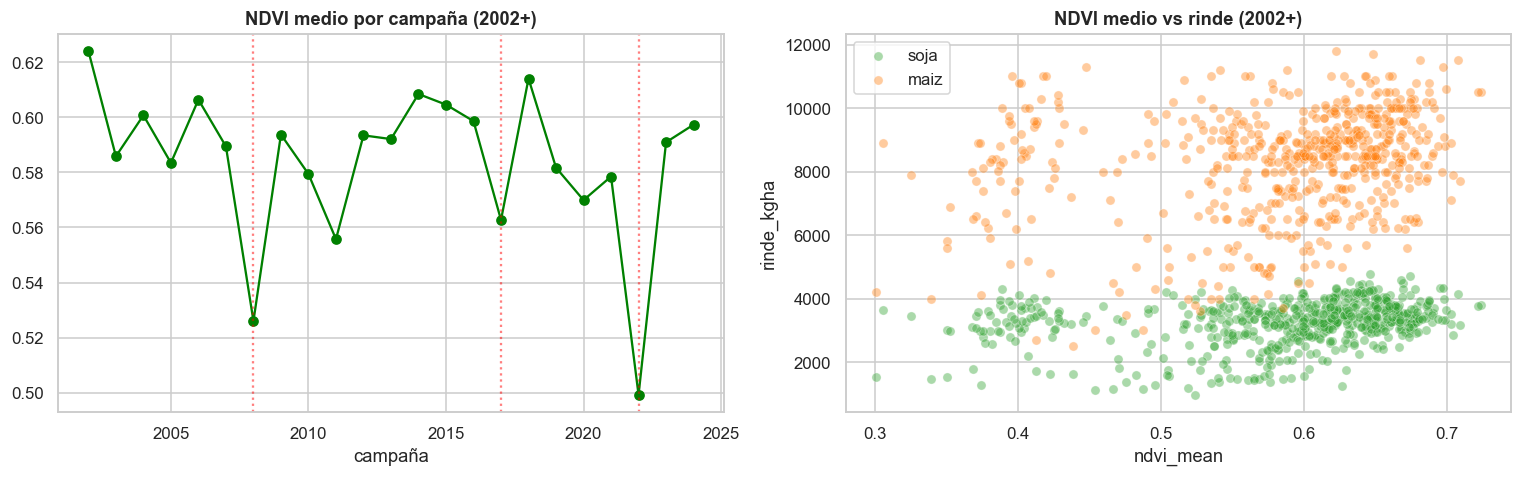

Correlación NDVI–rinde (2002+):
  soja: 0.271
  maiz: 0.237


In [61]:
# NDVI solo tiene sentido en el subset 2002+ (antes no existe)
ndvi_sub = df[df["campania_inicio"] >= 2002].copy()
print("Subset 2002+:", ndvi_sub.shape,
      f"| NaN en ndvi_mean: {ndvi_sub['ndvi_mean'].isna().mean()*100:.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
nd = ndvi_sub.groupby("campania_inicio")["ndvi_mean"].mean()
axes[0].plot(nd.index, nd.values, marker="o", color="green")
for y in SEQUIAS:
    if y >= 2002:
        axes[0].axvline(y, color="red", ls=":", alpha=.5)
axes[0].set_title("NDVI medio por campaña (2002+)"); axes[0].set_xlabel("campaña")

for cult in ["soja", "maiz"]:
    g = ndvi_sub[ndvi_sub["cultivo"] == cult].dropna(subset=["ndvi_mean"])
    sns.scatterplot(data=g, x="ndvi_mean", y=TARGET, ax=axes[1],
                    label=cult, color=CROP_COLORS[cult], alpha=.4)
axes[1].set_title("NDVI medio vs rinde (2002+)"); axes[1].legend()
plt.tight_layout(); plt.show()

print("Correlación NDVI–rinde (2002+):")
for cult in ["soja", "maiz"]:
    g = ndvi_sub[ndvi_sub["cultivo"] == cult]
    print(f"  {cult}: {g[['ndvi_mean', TARGET]].corr().iloc[0,1]:.3f}")

ValueError: Could not interpret value `_rinde_resid_pct` for `y`. An entry with this name does not appear in `data`.

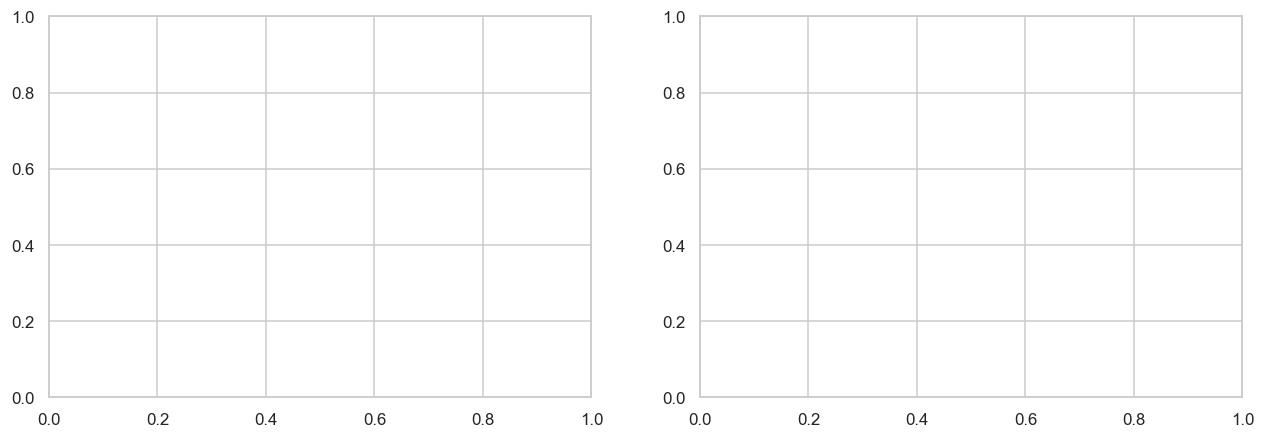

In [60]:
# Precipitación de verano (dic-ene-feb, período crítico) vs anomalía de rinde
df["_precip_verano"] = df[["prectotcorr_dic", "prectotcorr_ene", "prectotcorr_feb"]].mean(axis=1)
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for ax, cult in zip(axes, ["soja", "maiz"]):
    g = df[df["cultivo"] == cult]
    sns.scatterplot(data=g, x="_precip_verano", y="_rinde_resid_pct", hue="_enso",
                    palette=ENSO_COLORS, ax=ax, alpha=.5)
    ax.axhline(0, color="black", lw=.8)
    ax.set_title(f"{cult}: precip verano (DEF) vs anomalía de rinde")
    ax.set_xlabel("precip media dic–feb (mm/día)"); ax.set_ylabel("% desvío vs tendencia")
plt.tight_layout(); plt.show()

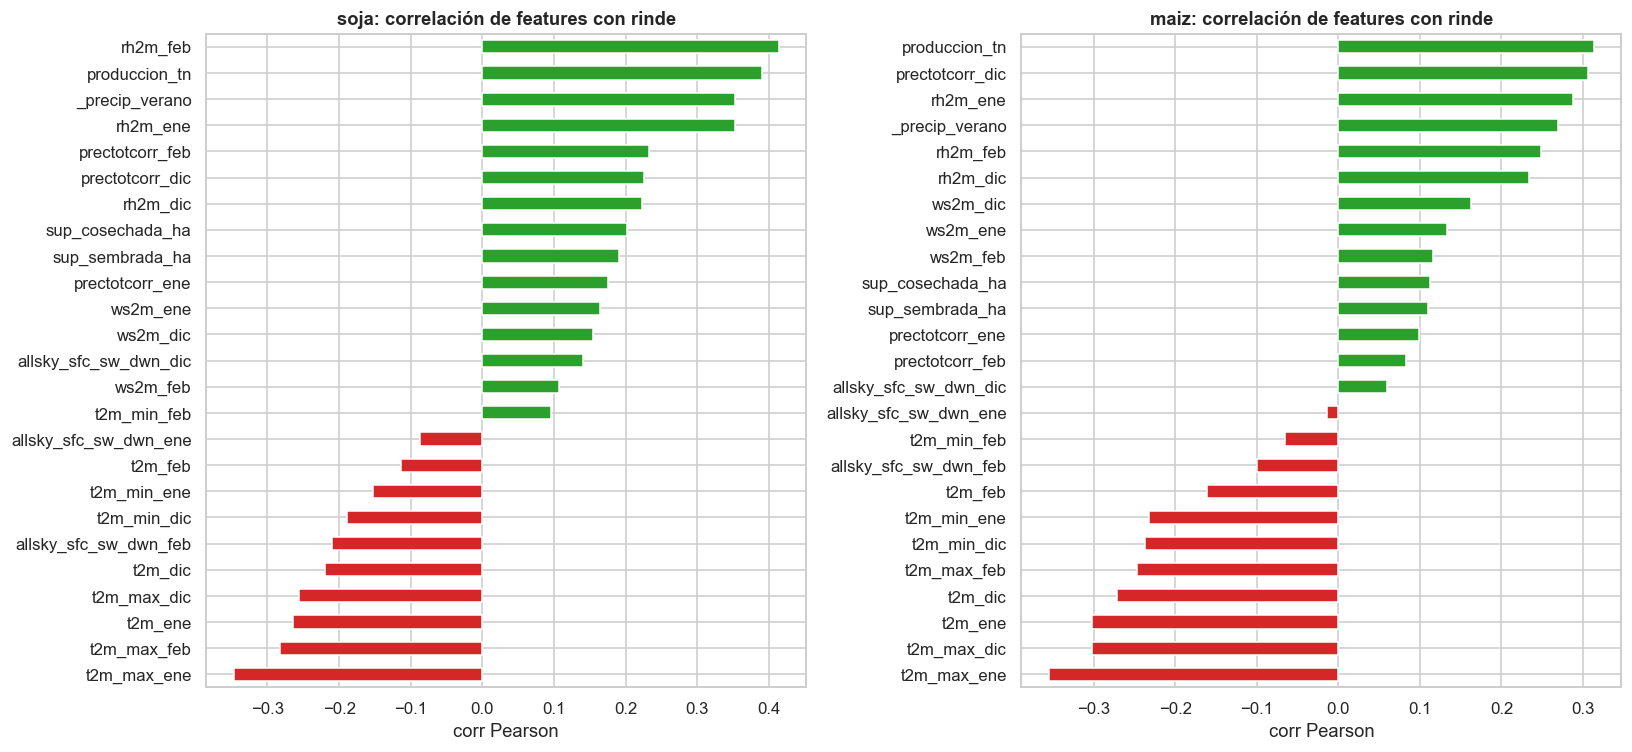

In [62]:
# Correlación de todas las features candidatas con el rinde, por cultivo
feat_pool = ([c for c in MAGYP_COLS if c in df.columns]
             + ["_oni_mean", "_precip_verano"]
             + [c for c in NASA_COLS if c.endswith(("_ene", "_dic", "_feb"))])
feat_pool = [c for c in feat_pool if c in df.columns]

fig, axes = plt.subplots(1, 2, figsize=(15, 7))
for ax, cult in zip(axes, ["soja", "maiz"]):
    g = df[df["cultivo"] == cult]
    corr = g[feat_pool + [TARGET]].corr()[TARGET].drop(TARGET).sort_values()
    corr.plot.barh(ax=ax, color=["#d62728" if v < 0 else "#2ca02c" for v in corr.values])
    ax.set_title(f"{cult}: correlación de features con rinde"); ax.set_xlabel("corr Pearson")
plt.tight_layout(); plt.show()

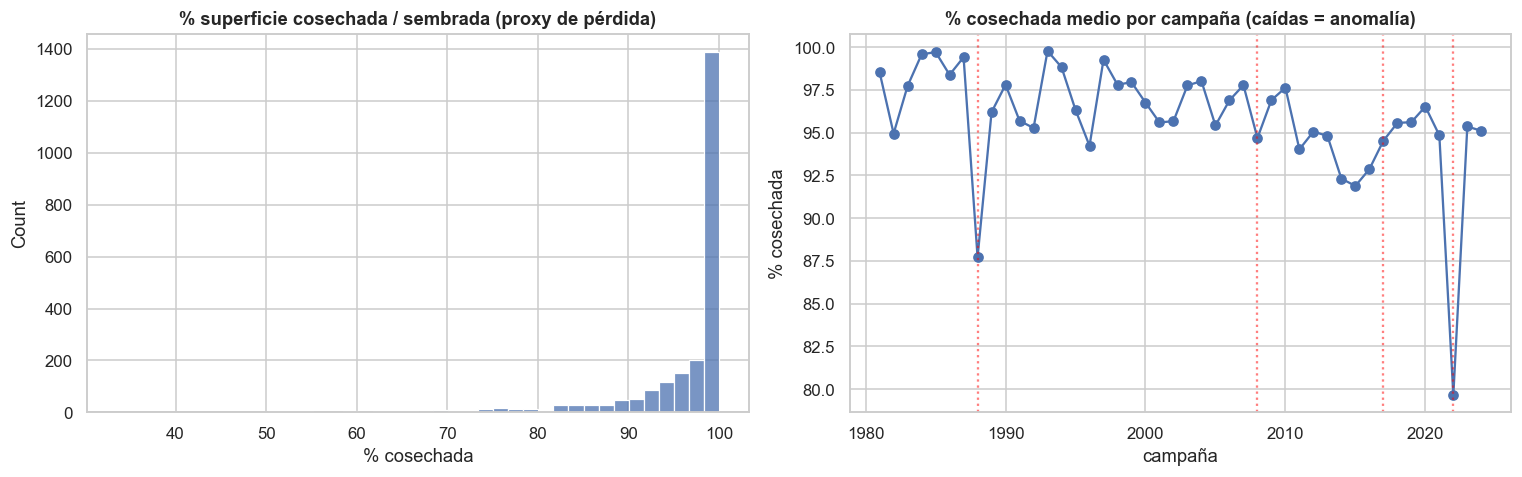

Campañas con más abandono (menor % cosechada):


campania_inicio
2022    79.6
1988    87.7
2015    91.9
2014    92.3
2016    92.9
Name: _pct_cosechada, dtype: float64

In [50]:
# % superficie cosechada/sembrada: proxy directo de pérdida/abandono por campaña
df["_pct_cosechada"] = df["sup_cosechada_ha"] / df["sup_sembrada_ha"] * 100
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sns.histplot(df["_pct_cosechada"], bins=40, ax=axes[0])
axes[0].set_title("% superficie cosechada / sembrada (proxy de pérdida)")
axes[0].set_xlabel("% cosechada")
loss = df.groupby("campania_inicio")["_pct_cosechada"].mean()
axes[1].plot(loss.index, loss.values, marker="o")
for y in SEQUIAS:
    axes[1].axvline(y, color="red", ls=":", alpha=.5)
axes[1].set_title("% cosechada medio por campaña (caídas = anomalía)")
axes[1].set_xlabel("campaña"); axes[1].set_ylabel("% cosechada")
plt.tight_layout(); plt.show()

print("Campañas con más abandono (menor % cosechada):")
display(loss.sort_values().head(5).round(1))

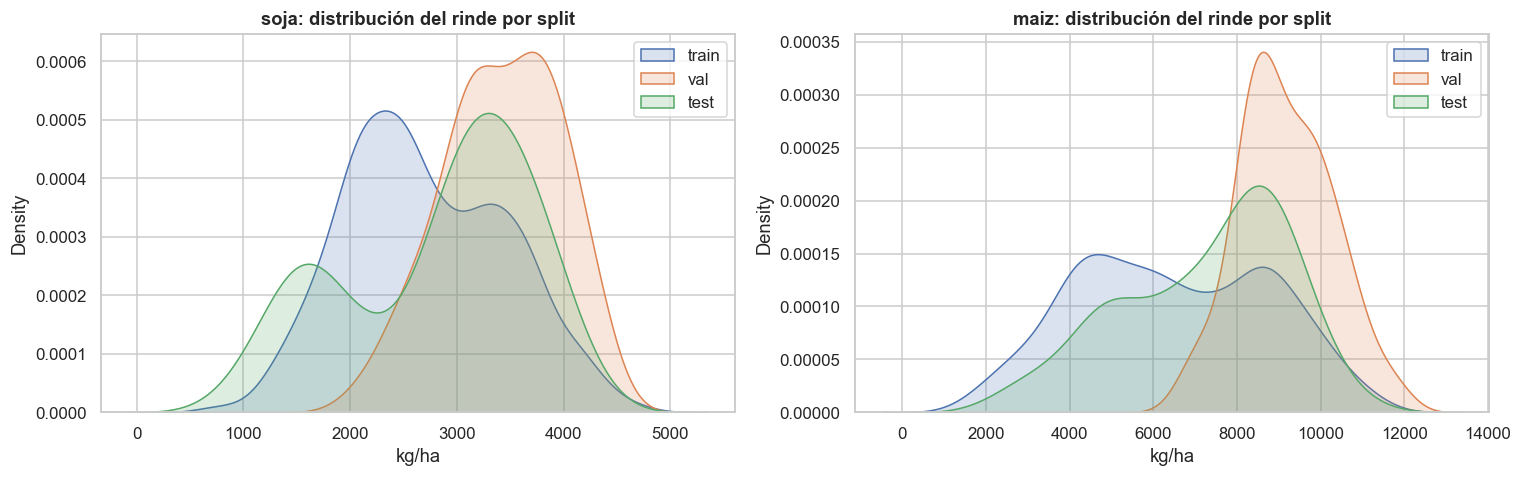

Rinde medio por split (la tendencia hace que val/test sean más altos):


cultivo,maiz,soja
split,,
test,7241.0,2817.0
train,6464.0,2701.0
val,9161.0,3419.0


In [51]:
# Distribution shift: ¿cambia la distribución del rinde entre train/val/test? (split temporal)
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for ax, cult in zip(axes, ["soja", "maiz"]):
    g = df[df["cultivo"] == cult]
    for sp in ["train", "val", "test"]:
        sns.kdeplot(g[g["split"] == sp][TARGET], ax=ax, label=sp, fill=True, alpha=.2)
    ax.set_title(f"{cult}: distribución del rinde por split"); ax.set_xlabel("kg/ha"); ax.legend()
plt.tight_layout(); plt.show()

print("Rinde medio por split (la tendencia hace que val/test sean más altos):")
display(df.pivot_table(index="split", columns="cultivo", values=TARGET, aggfunc="mean").round(0))

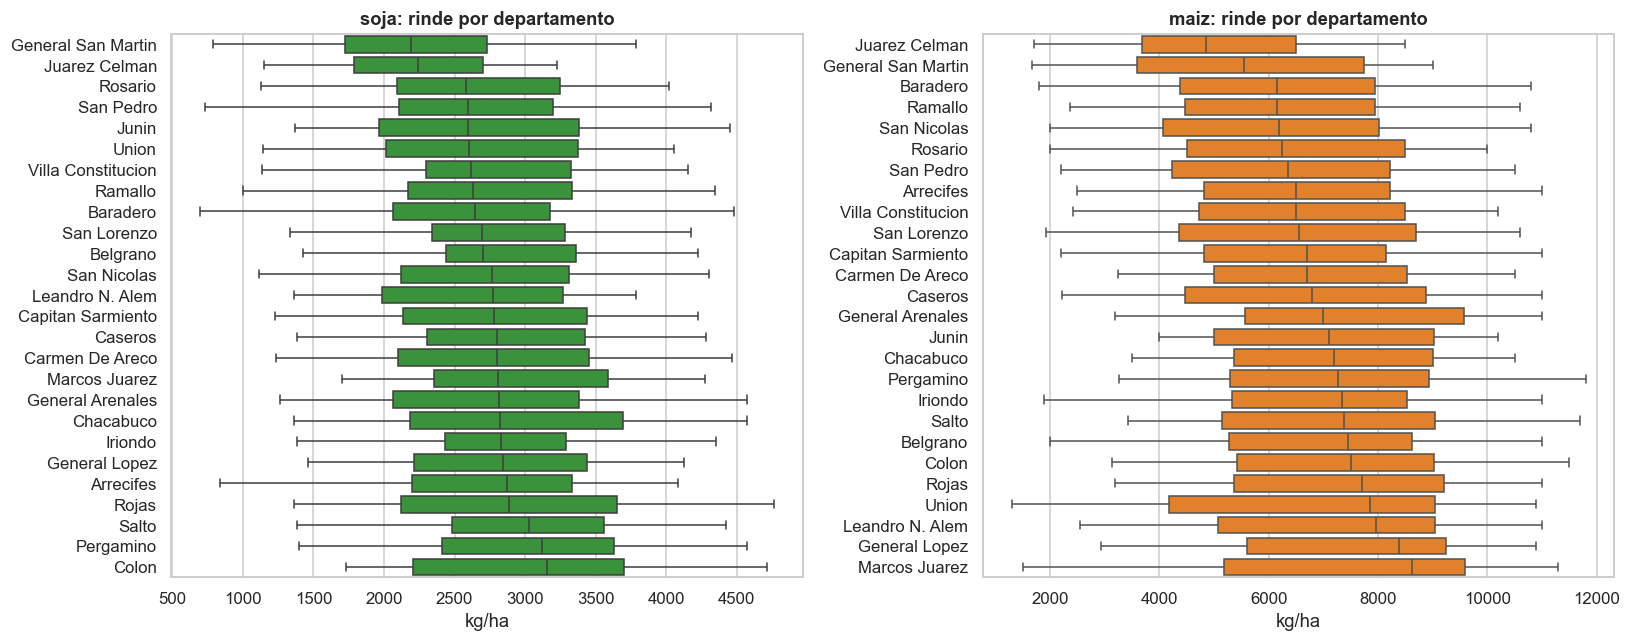

In [52]:
# Heterogeneidad espacial: rinde por departamento (ordenado por mediana)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, cult in zip(axes, ["soja", "maiz"]):
    g = df[df["cultivo"] == cult]
    order = g.groupby("departamento")[TARGET].median().sort_values().index
    sns.boxplot(data=g, y="departamento", x=TARGET, order=order, ax=ax,
                color=CROP_COLORS[cult], fliersize=2)
    ax.set_title(f"{cult}: rinde por departamento"); ax.set_xlabel("kg/ha"); ax.set_ylabel("")
plt.tight_layout(); plt.show()